# 05. Model Explainability & Analysis

**Goal:** Perform a complete due diligence on the Tuned XGBoost Champion vs. the BayesianRidge Baseline. We go from global importance, through SHAP analysis, to single-stock explanations.

**Context:** Our tuning championship gave us two finalists:
1. **The Tuned Champion:** XGBoost (Optuna-tuned, highest R²).
2. **The Stable Baseline:** BayesianRidge (simple, linear).

The Champion is *quantitatively* better, but in a hedge fund, you never "bet millions on a black box." We must "pop the hood" to see *how* it's making decisions.

**Structure:**
- **Part 1:** Fit both models, compare default feature importances.
- **Part 2:** SHAP analysis — the "truth" about what drives the model.
- **Part 3:** Investigate why XGBoost's default importance can mislead.
- **Part 4:** Final Briefing — interaction effects, PDPs, sector drivers, banking crisis case study, and single-stock explanations.

In [5]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import joblib

sys.path.append(os.path.abspath('..'))

from src.utils.logger import setup_logger

logger = setup_logger("05_explainability")

# Load Processed Data
data_path = "../data/processed/final_model_data.parquet"
if os.path.exists(data_path):
    df = pd.read_parquet(data_path)
    logger.info(f"Data Loaded. Shape: {df.shape}")
else:
    logger.error("Data file not found. Run Notebook 02 first.")

2026-03-07 14:37:12,681 - INFO - Data Loaded. Shape: (93829, 94)


### Data Preparation

We use the same 2023+ evaluation window and feature isolation as Notebooks 03–04. The `FwdRetOrig` column (unclipped returns) is excluded from features but preserved in the DataFrame for later use.

In [6]:
# Filter for recent regime (2023 onwards)
gdf = df.loc[df.index.get_level_values(0) >= pd.Timestamp('2023-01-01')].copy()

target_col = 'FwdRet'

# Explicitly exclude target columns
exclude_cols = [target_col, 'FwdRetOrig']
feature_cols = [c for c in gdf.columns if c not in exclude_cols]

X_full = gdf[feature_cols].copy()
y_full = gdf[target_col].copy()

# Clean NaNs
mask = X_full.notna().all(axis=1) & y_full.notna()
X_clean = X_full.loc[mask].copy()
y_clean = y_full.loc[mask].copy()

print(f"X_clean shape: {X_clean.shape}")
print(f"y_clean length: {len(y_clean)}")

X_clean shape: (8971, 92)
y_clean length: 8971


---

## Part 1: The Initial Investigation

We fit both models and compare their "brains" — the BayesianRidge coefficients vs. XGBoost's default feature importances.

In [7]:
import xgboost as xgb
from xgboost import XGBRegressor
import shap
from sklearn.linear_model import BayesianRidge

# Version checks
print(f"XGBoost version: {xgb.__version__}")
print(f"SHAP version: {shap.__version__}")
print(f"X_clean shape: {X_clean.shape}")
print(f"y_clean length: {len(y_clean)}")

# 1. Fit the BayesianRidge baseline
br_model = BayesianRidge()
br_model.fit(X_clean, y_clean)
print("BayesianRidge model fitted.")

# 2. Fit the Tuned XGBoost Champion
# Load saved model from Notebook 04, or instantiate with Optuna-winning params
model_path = "../models/xgb_champion.joblib"
if os.path.exists(model_path):
    xgb_champion = joblib.load(model_path)
    print(f"Loaded XGBoost champion from {model_path}")
    # Re-fit on the current X_clean/y_clean
    xgb_champion.fit(X_clean, y_clean)
else:
    logger.warning("No saved model found. Instantiating with config params.")
    # Fallback: use your Optuna-winning params here
    xgb_champion = XGBRegressor(
        n_estimators=593,
        max_depth=5,
        learning_rate=0.023324877778608765,
        subsample=0.7538740745529875,
        colsample_bytree=0.7615464432458687,
        reg_lambda=5.01325529529293,
        objective="reg:squarederror",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    )
    xgb_champion.fit(X_clean, y_clean)

print("Tuned XGBoost Champion model fitted.")

XGBoost version: 2.1.4
SHAP version: 0.49.1
X_clean shape: (8971, 92)
y_clean length: 8971
BayesianRidge model fitted.
Loaded XGBoost champion from ../models/xgb_champion.joblib


/Users/aengusmartindonaire/.conda/envs/hedging_clean/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [14:37:21] WARNING: /Users/runner/work/xgboost/xgboost/src/gbm/../common/error_msg.h:80: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  warnings.warn(smsg, UserWarning)


Tuned XGBoost Champion model fitted.


#### Global Importance for BayesianRidge (Plot 1)

The BayesianRidge model has a single coefficient per feature. We extract the Top 20 by absolute magnitude, keeping the original sign to show direction.

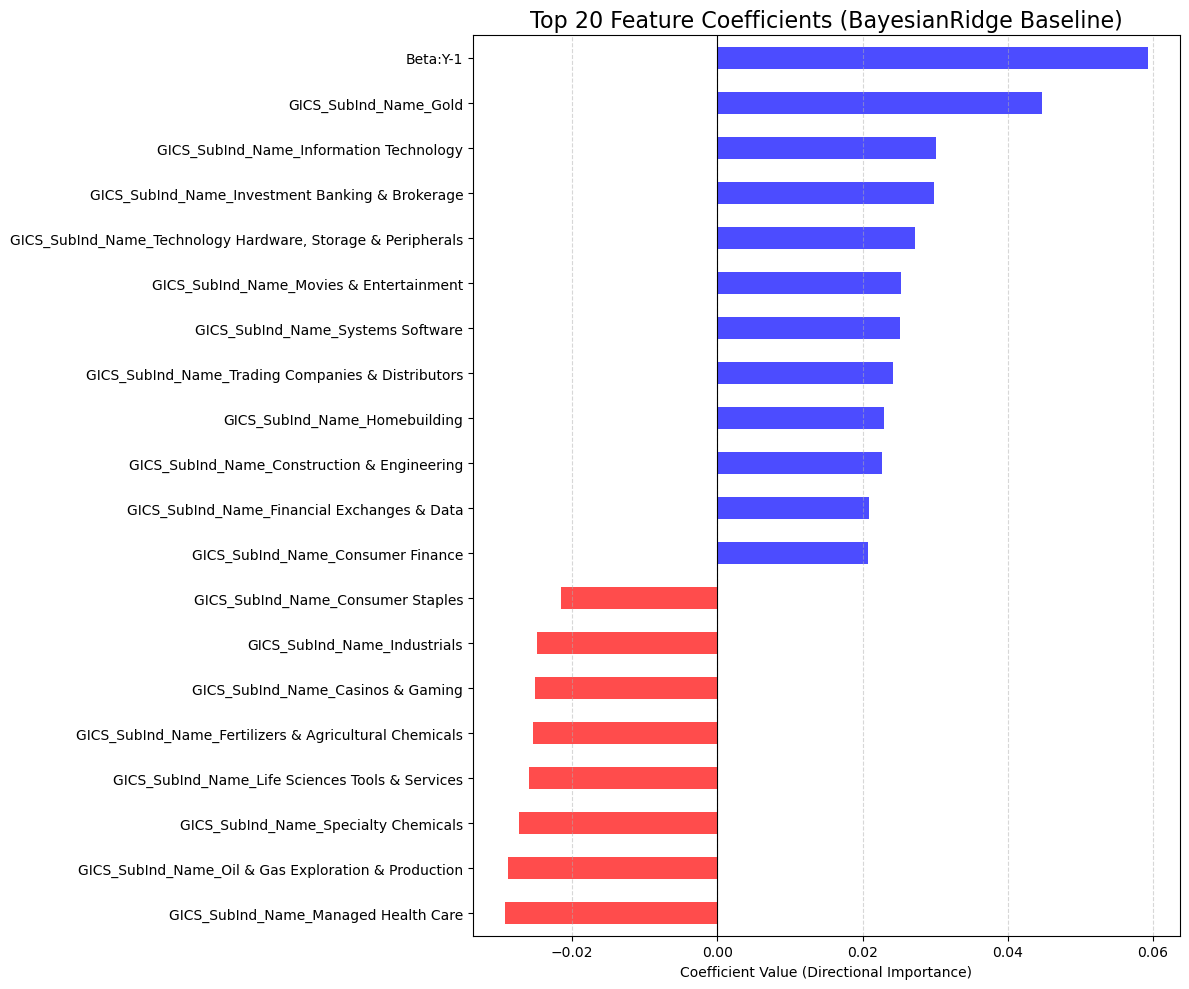

In [4]:
# Extract coefficients as a Pandas Series, indexed by feature name
br_importances = pd.Series(br_model.coef_, index=X_clean.columns)

# Identify the Top 20 by absolute magnitude, keep original sign
br_top_20 = br_importances.abs().sort_values(ascending=False).head(20)
br_plot_data = br_importances.loc[br_top_20.index].sort_values(ascending=True)

# Plot
plt.figure(figsize=(12, 10))
colors = ['red' if x < 0 else 'blue' for x in br_plot_data]
br_plot_data.plot(kind='barh', color=colors, alpha=0.7)
plt.title('Top 20 Feature Coefficients (BayesianRidge Baseline)', fontsize=16)
plt.xlabel('Coefficient Value (Directional Importance)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Global Importance for XGBoost (Plot 2)

XGBoost's default `feature_importances_` uses the **gain** metric — the average improvement in the loss function when a feature is used to split. We'll later see why this can be misleading.

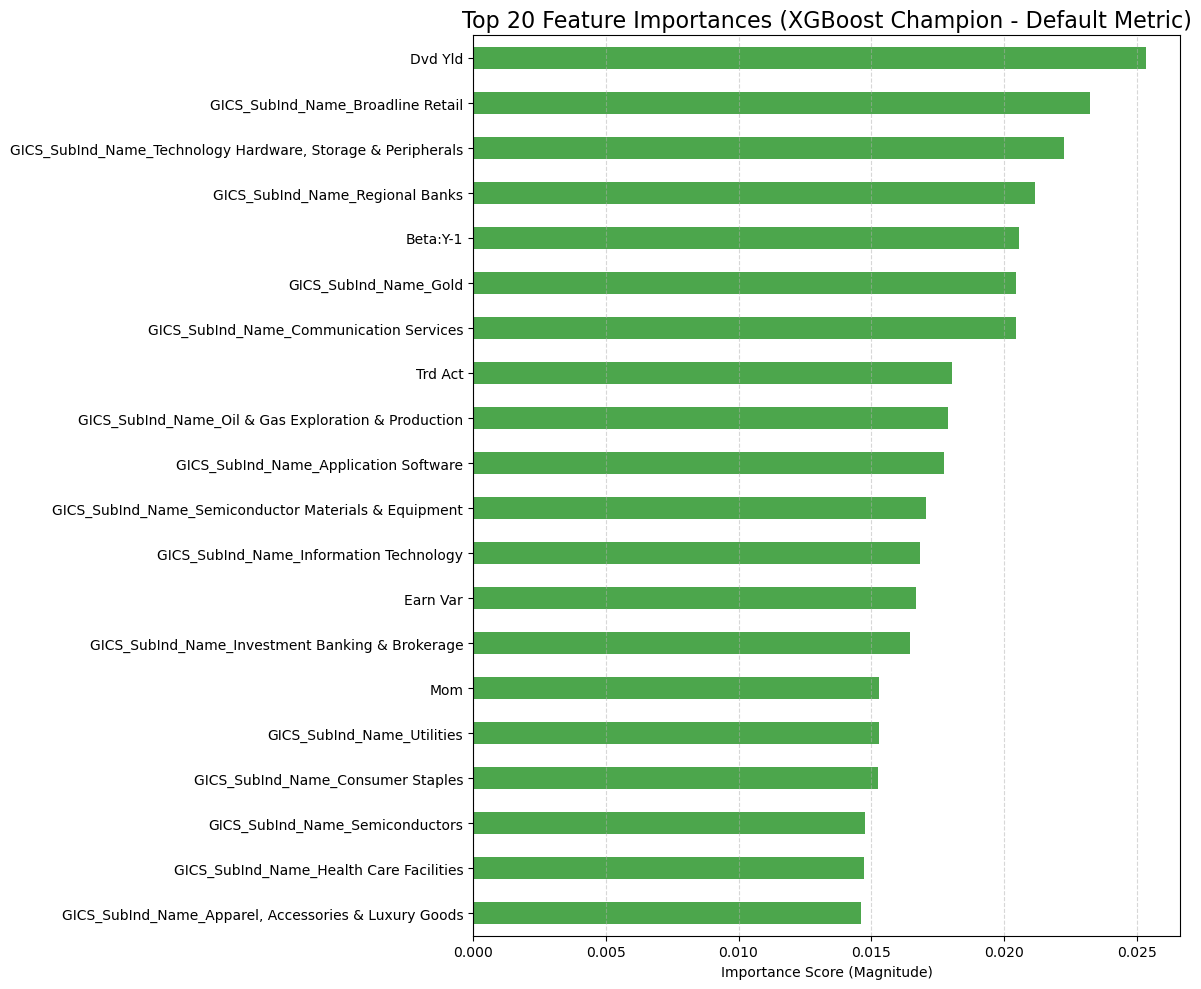

In [5]:
# Extract default feature importances from the fitted XGBoost model
xgb_importances = pd.Series(xgb_champion.feature_importances_, index=X_clean.columns)

# Take the Top 20 features
xgb_plot_data = xgb_importances.sort_values(ascending=False).head(20).sort_values(ascending=True)

# Plot
plt.figure(figsize=(12, 10))
xgb_plot_data.plot(kind='barh', color='green', alpha=0.7)
plt.title('Top 20 Feature Importances (XGBoost Champion - Default Metric)', fontsize=16)
plt.xlabel('Importance Score (Magnitude)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Quick Overlap Check (Plot 1 vs Plot 2)

Before moving to SHAP, we check how much the two models agree on which features matter.

In [6]:
# Top 20 feature names from each model
br_top_20_list = br_plot_data.index.tolist()
xgb_top_20_list = xgb_plot_data.index.tolist()

# Features in BOTH Top 20 lists
common_features = set(br_top_20_list) & set(xgb_top_20_list)

print("--- Due Diligence Check ---")
print(f"Features in Top 20 for *both* models: {len(common_features)}")
print("\nHigh-Conviction Features:")
for f in sorted(list(common_features)):
    print(f"  - {f}")

--- Due Diligence Check ---
Features in Top 20 for *both* models: 7

High-Conviction Features:
  - Beta:Y-1
  - GICS_SubInd_Name_Consumer Staples
  - GICS_SubInd_Name_Gold
  - GICS_SubInd_Name_Information Technology
  - GICS_SubInd_Name_Investment Banking & Brokerage
  - GICS_SubInd_Name_Oil & Gas Exploration & Production
  - GICS_SubInd_Name_Technology Hardware, Storage & Peripherals


**Observations:**

- **7 shared "high-conviction" features:** Both models flag `Beta:Y-1` and six specific GICS subindustries (Consumer Staples, Gold, Information Technology, Investment Banking & Brokerage, Oil & Gas E&P, Technology Hardware).

- **BayesianRidge is a sector-rotation model:**
  - The Top 20 is almost entirely GICS subindustry dummies, plus `Beta:Y-1` as the single dominant factor.
  - Positive coefficients concentrate in cyclical/growthy/financial areas: Gold, Information Technology, Investment Banking, Tech Hardware, Movies & Entertainment, Systems Software, Trading Companies, Homebuilding, Construction & Engineering, Financial Exchanges, Consumer Finance.
  - Negative coefficients fall on defensive or regulated segments: Consumer Staples, Industrials, Casinos & Gaming, Fertilizers & Ag Chemicals, Life Sciences Tools, Specialty Chemicals, Oil & Gas E&P, Managed Health Care.
  - None of the other Bloomberg risk/valuation factors (`Dvd Yld`, `Trd Act`, `Earn Var`, `Mom`, `Gr`, `BEst` ratios) appear in the Top 20.

- **XGBoost brings in the risk/valuation factors:**
  - `Dvd Yld` is the #1 feature overall.
  - `Beta:Y-1`, `Trd Act`, `Earn Var`, and `Mom` all appear in the Top 20 alongside subindustries.
  - The model also elevates subindustries not seen in BayesianRidge: Broadline Retail (#2), Regional Banks, Communication Services, Application Software, Semiconductor Materials & Equipment, Utilities, Semiconductors, and Health Care Facilities.
  - This suggests the tree model is capturing cross-sectional factor effects *and* more granular sector signals that the linear model misses.

- **Overall conclusion:** The two models partly agree (Beta and a cluster of subindustries are clearly important), but they are not telling the same story. The linear baseline explains returns mostly via sector tilts plus a single beta exposure. The XGBoost champion adds a strong multi-factor dimension (especially Dividend Yield, Trading Activity, Earnings Variability, and Momentum) alongside richer sector discrimination.

---

## Part 2: The Truth — SHAP Analysis

The default `feature_importances_` might be misleading. To see the *true* impact of each feature on predictions, we use **SHAP (SHapley Additive exPlanations)**.

**Key concepts:**
- SHAP values give the *exact* contribution of each feature to each prediction.
- Each cell in the SHAP matrix shows how that feature value *for that specific stock* pushed the prediction away from the baseline.
- All SHAP values for a single stock sum to: `prediction - expected_value`.

**Sampling Strategy:** We use 1,000 stocks (instead of all ~9,000) for computational efficiency. Individual explanations remain exact, and global patterns are stable at this sample size.

In [8]:
# Initialize SHAP TreeExplainer and compute values
print("Initializing SHAP...")

# We re-fit with an explicit base_score to work around this.
xgb_champion.set_params(base_score=float(y_clean.mean()))
xgb_champion.fit(X_clean, y_clean)

# Create the TreeExplainer for the tuned XGBoost champion
explainer = shap.TreeExplainer(xgb_champion)

# Sample 1,000 observations for speed and stability
X_sample = X_clean.sample(1000, random_state=42)

# Compute SHAP values
shap_values = explainer(X_sample)

print("SHAP values calculated.")
print(f"SHAP values matrix shape: {shap_values.values.shape}")
print(f"Expected value (baseline prediction): {explainer.expected_value:.6f}")

Initializing SHAP...
SHAP values calculated.
SHAP values matrix shape: (1000, 92)
Expected value (baseline prediction): 0.043074


#### SHAP Sanity Check

We verify that SHAP gives an exact additive decomposition: `prediction = expected_value + sum(SHAP values)` for any given stock.

In [8]:
# SHAP sanity check on a single random stock
stock_idx = 0

# Model prediction for that stock
prediction = xgb_champion.predict(X_sample.iloc[[stock_idx]])[0]

# SHAP-based reconstruction
shap_sum = explainer.expected_value + shap_values.values[stock_idx].sum()

print("SHAP Sanity Check")
print(f"Stock prediction:             {prediction:.6f}")
print(f"Expected value + SHAP sum:    {shap_sum:.6f}")
print(f"Match: {np.isclose(prediction, shap_sum)}")

SHAP Sanity Check
Stock prediction:             0.008648
Expected value + SHAP sum:    0.008648
Match: True


The match confirms SHAP is giving an **exact additive decomposition** of the XGBoost prediction:

$$f(x) = \text{expected\_value} + \sum_j \text{SHAP}_{j}(x)$$

We are working with the model's actual predictions, not an approximate heuristic.

#### SHAP Summary Plot (Bar) — Global Importance (Plot 3)

This ranks features by **mean absolute SHAP value** across the 1,000 sampled stocks — the most reliable global importance metric.

SHAP Global Importance (Bar Plot)


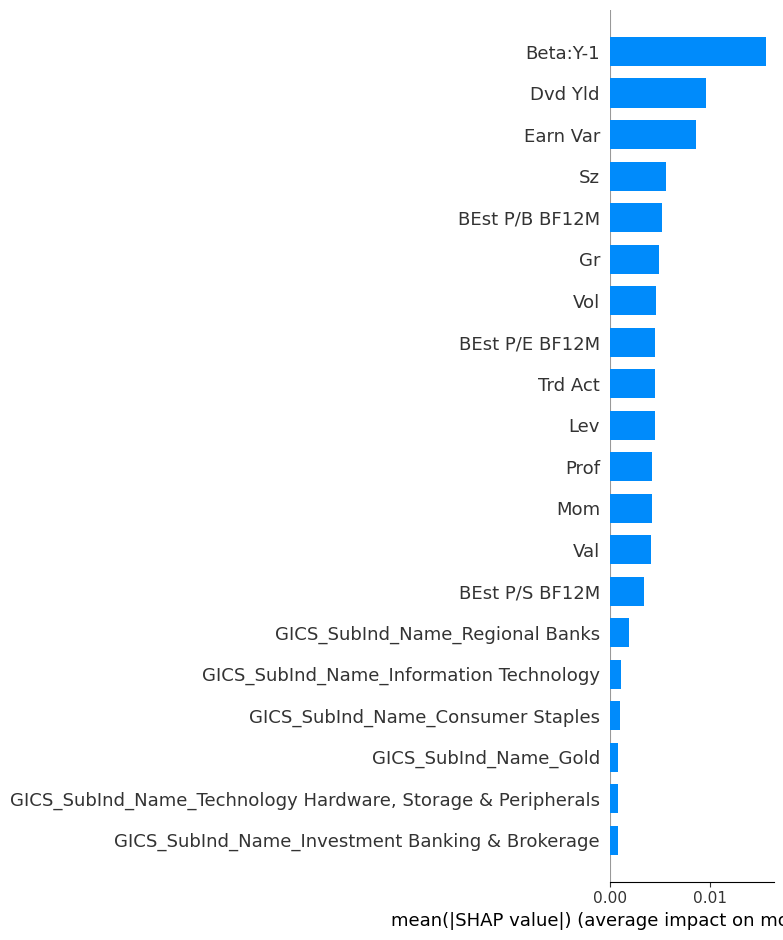

In [9]:
print("SHAP Global Importance (Bar Plot)")
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar",
    show=True
)

**Key takeaway:** SHAP's global ranking confirms the XGBoost champion is overwhelmingly driven by **core Bloomberg risk factors**, not sector tilts. `Beta:Y-1` dominates by a wide margin, followed by `Dvd Yld` and `Earn Var`. All 14 numerical factors (`Sz`, `BEst P/B BF12M`, `Gr`, `Vol`, `BEst P/E BF12M`, `Trd Act`, `Lev`, `Prof`, `Mom`, `Val`, `BEst P/S BF12M`) appear before any GICS subindustry. The six subindustries that do appear — Regional Banks, Information Technology, Consumer Staples, Gold, Tech Hardware, and Investment Banking — are secondary refinements layered on top of the factor structure. 

> This is a **multi-factor model with some sector seasoning**, not a sector-timing black box.

#### SHAP Summary Plot (Dot) — Direction + Magnitude (Plot 4)

Same feature order as the bar plot, but each point is one stock. The x-axis shows the SHAP value (impact), and the color shows the actual feature value (blue = low, red = high). This reveals both magnitude and direction.

SHAP Global Importance (Dot Plot)


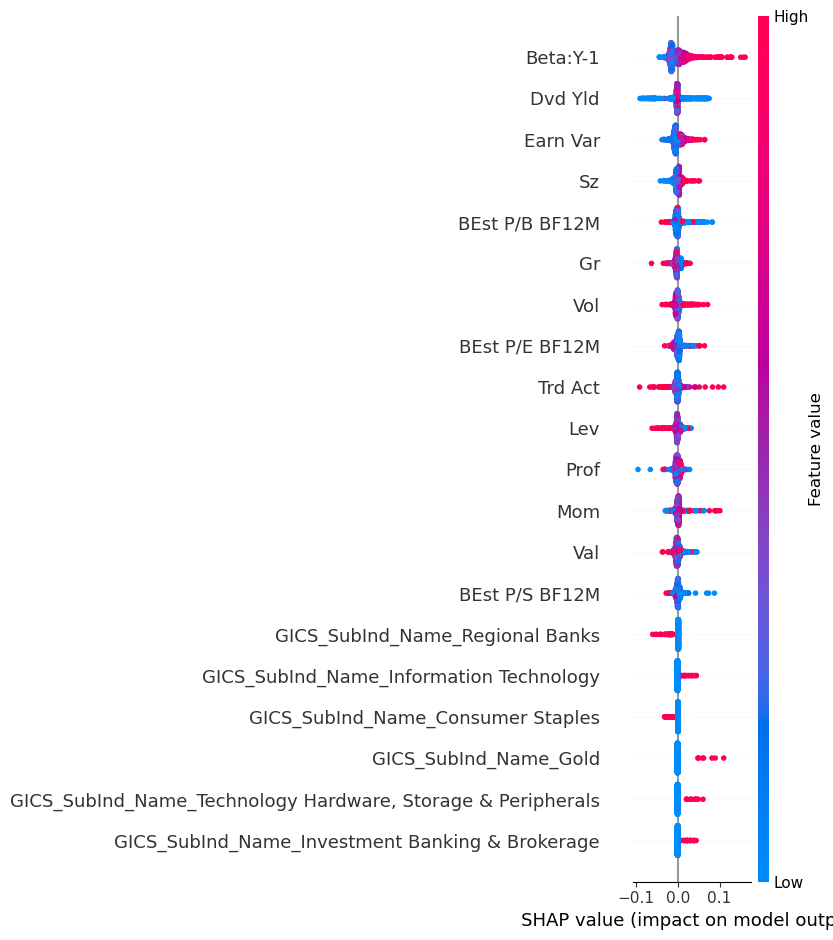

In [10]:
print("SHAP Global Importance (Dot Plot)")
shap.summary_plot(
    shap_values,
    X_sample,
    show=True
)

**Key patterns:**

- **`Beta:Y-1`:** The clearest signal in the model. High beta (red) pushes strongly to the RIGHT (positive SHAP); low beta (blue) pushes LEFT (negative SHAP). Higher beta unambiguously raises predicted returns — and the magnitude is the largest of any feature.

- **`Dvd Yld`:** Inverted pattern — low dividend yield (blue) spreads to the RIGHT (positive SHAP), while high dividend yield (red) clusters LEFT (negative SHAP). The model penalizes high-yield stocks and favors low-yield names, consistent with a growth-over-income regime in the 2023–2025 sample.

- **`Earn Var`:** High earnings variability (red) tends RIGHT (positive SHAP); low variability (blue) tends LEFT (negative SHAP). The model rewards stocks with higher earnings volatility — potentially capturing catalyst-driven names — and penalizes very stable earners as "low-alpha defensives."

- **`Sz`:** High size (red) pushes RIGHT; low size (blue) pushes LEFT. Larger-cap stocks are systematically preferred over small-cap names.

- **`BEst P/B BF12M`:** Inverted — low P/B (blue) spreads RIGHT (positive SHAP), high P/B (red) spreads LEFT. Cheap-on-book stocks are rewarded; expensive ones are penalized. A classic value signal.

- **`Gr`, `Mom`:** Both show the expected pattern — high values (red) push predictions up, low values (blue) push down. Growth and momentum are rewarded.

- **`Vol`:** High volatility (red) shows spread in both directions, suggesting a conditional or non-linear relationship. The model uses volatility contextually rather than as a simple directional signal.

- **`Trd Act`:** High activity (red) spreads to BOTH sides — positive and negative SHAP — while low activity (blue) clusters near zero. The model's treatment of trading activity depends heavily on what other features look like.

- **`BEst P/E BF12M`, `BEst P/S BF12M`:** Both show value-like patterns — low values (blue, i.e., cheap multiples) tend RIGHT, while high values (red, expensive) tend LEFT.

- **Subindustry dummies:** When the dummy is active (red = 1):
  - **Regional Banks** → strongly LEFT (negative SHAP). The model penalizes regional bank membership.
  - **Consumer Staples** → LEFT (negative). Defensives are discounted in this regime.
  - **Information Technology, Gold, Tech Hardware, Investment Banking** → RIGHT (positive). The model rewards these cyclical/growth/thematic sectors.

> The dot plot confirms the model uses features in **economically sensible directions**: high beta, growth, momentum, and size push returns up; cheap valuations (low P/B, P/E, P/S) are rewarded; high dividend yield is penalized (growth > income in this regime); and sector dummies add targeted tilts — long tech/gold/defense, short regional banks/staples.

#### SHAP Partial Dependence Plot (Plot 5)

The PDP isolates a single feature's average "main effect" by holding all other features constant and sweeping the target feature across its range.

In [11]:
# Make a purely numeric copy of X_sample for partial dependence
X_sample_num = X_sample.copy()
X_sample_num = X_sample_num.apply(pd.to_numeric, errors='coerce')

# Wrapper so SHAP always calls XGBoost with numeric data
def xgb_predict_numeric(X):
    if isinstance(X, pd.DataFrame):
        X_numeric = X.apply(pd.to_numeric, errors='coerce')
        return xgb_champion.predict(X_numeric)
    else:
        return xgb_champion.predict(X)

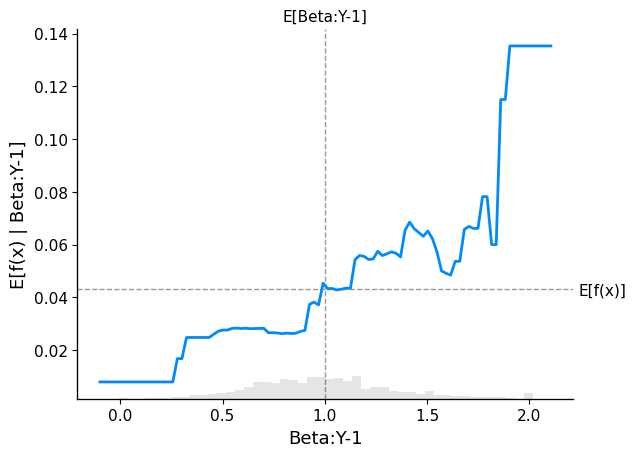

In [12]:
feature_to_plot = 'Beta:Y-1'

shap.partial_dependence_plot(
    feature_to_plot,
    xgb_predict_numeric,
    X_sample_num,
    model_expected_value=True,
    feature_expected_value=True,
    ice=False
)

**Beta:Y-1 PDP interpretation:**
- At very low beta (~0), expected returns sit around **1%** — well below the global mean of ~4.4% (`E[f(x)]`).
- The curve rises gradually through the 0.3–0.9 range, reaching about **3%** — still below baseline.
- Around **beta ≈ 1.0** (the mean, marked by the vertical dashed line), the curve crosses the baseline at ~**4.5–5%**.
- For beta > 1, the curve steepens: by ~1.3 it reaches **5.5–6%**, with some local wiggles around 1.4–1.6.
- Above **beta ≈ 1.7**, the curve jumps sharply — reaching **8%** by ~1.8 and peaking near **13.5%** at beta ≈ 2.0.
- The grey histogram shows most stocks cluster between 0.6 and 1.4, so the central portion of the curve is well-supported by data. The extreme high-beta region (>1.7) has fewer observations and should be interpreted cautiously.

> The partial dependence plot reinforces SHAP: `Beta:Y-1` has a **clear, monotone, economically plausible effect** — higher beta is associated with higher expected forward returns. The relationship is nonlinear: the marginal reward for each unit of beta accelerates above 1.0, and especially above 1.7, where expected returns more than triple compared to low-beta names.

---

## Part 3: The Investigation — What Went Wrong?

SHAP tells a potentially very different story than the default `feature_importances_`. Why?

XGBoost has **four** importance metrics:
- **`weight`:** How many times was this feature used to split? (Activity count)
- **`gain`:** Average improvement per split (the default — what Plot 2 showed)
- **`total_gain`:** Cumulative improvement across all splits (weight × gain)
- **`cover`:** How many samples were affected by splits on this feature?

We compare all four to understand the discrepancy.

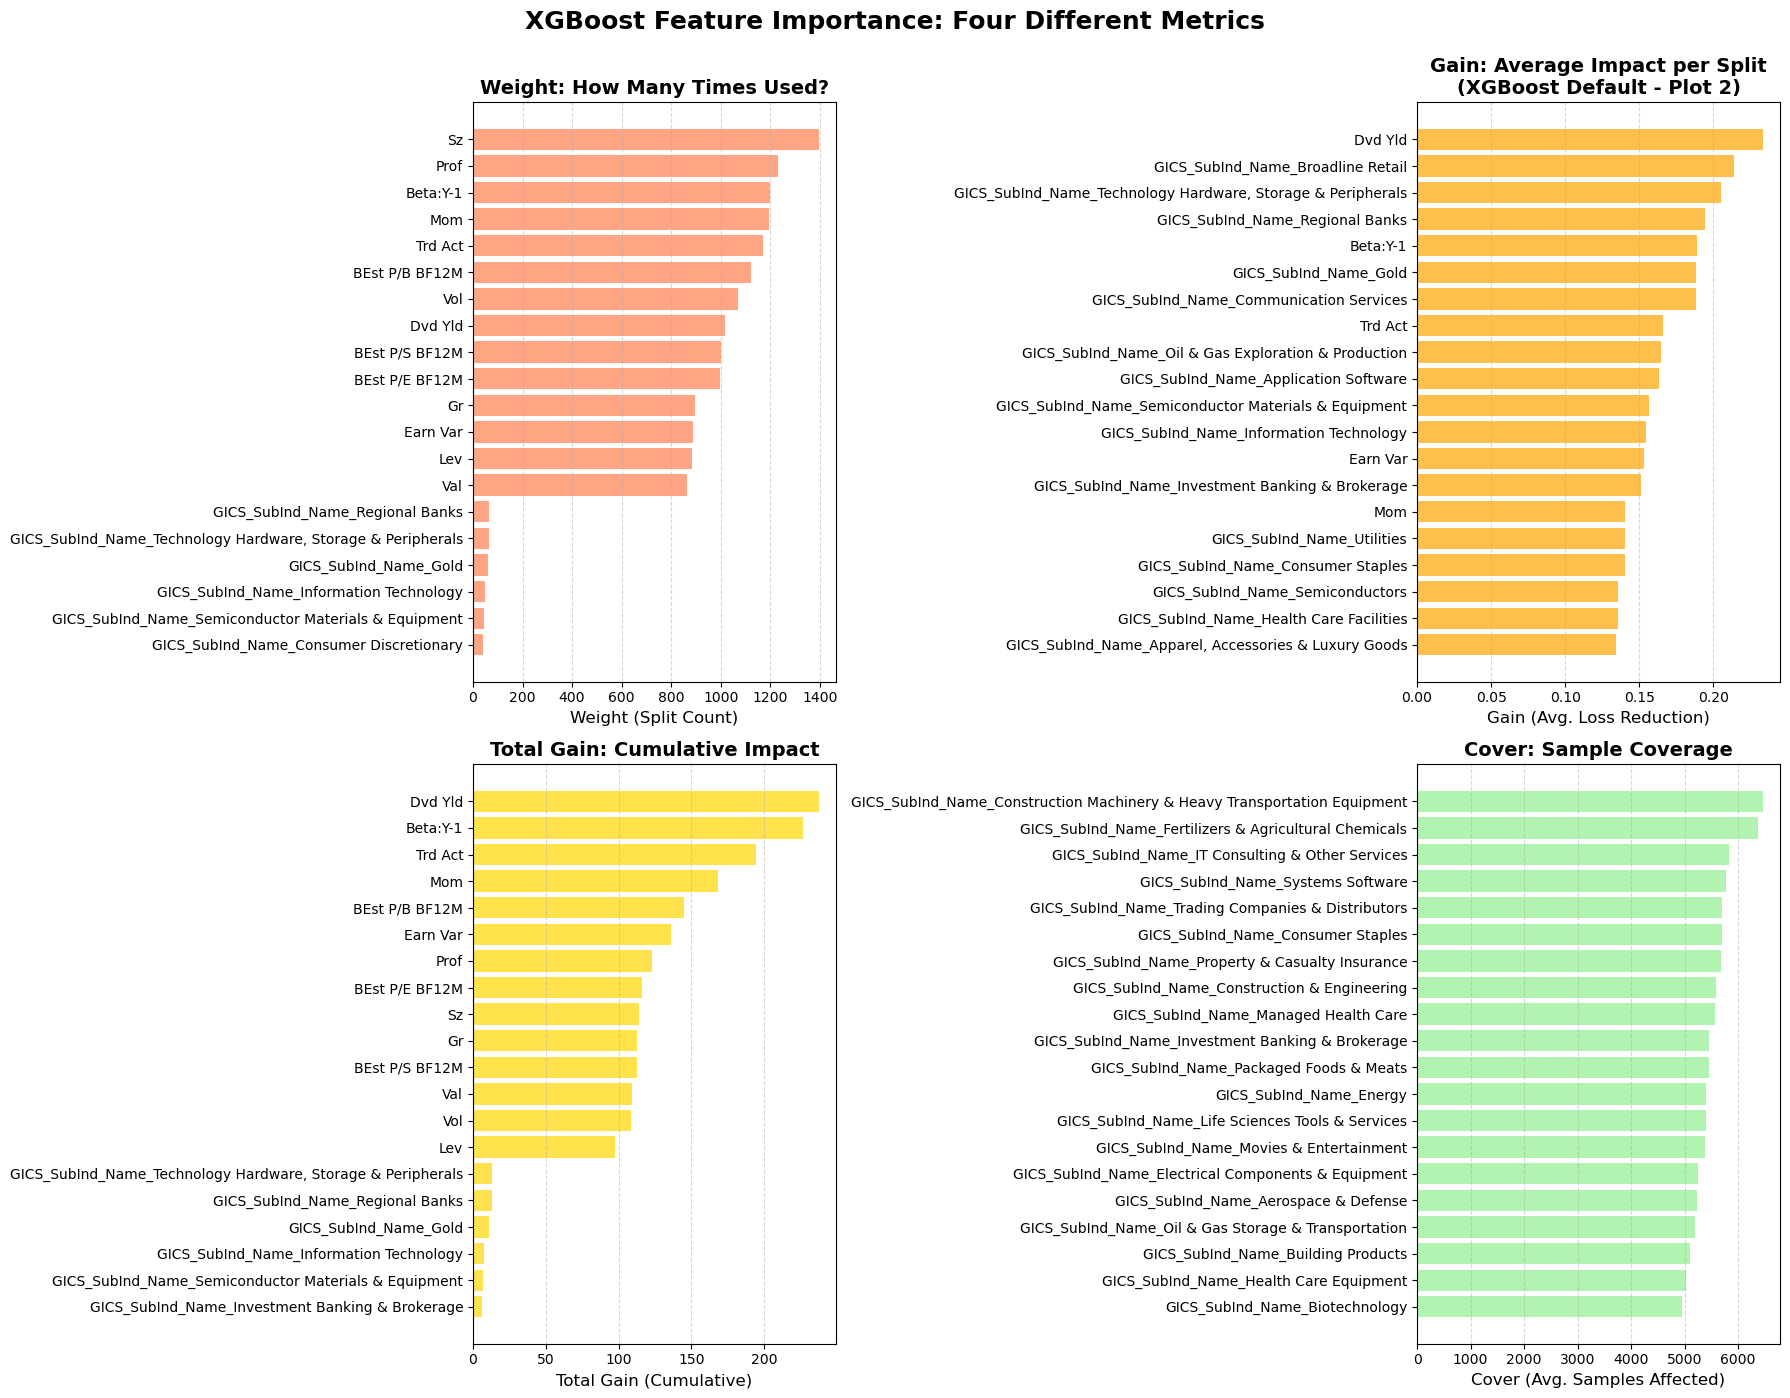


=== Top Feature by Each Metric ===
Weight:      Sz
Gain:        Dvd Yld
Total Gain:  Dvd Yld
Cover:       GICS_SubInd_Name_Construction Machinery & Heavy Transportation Equipment

=== Features in Top 20 for ALL metrics (Consensus) ===
Count: 0
No features appear in all four Top 20 lists!


In [13]:
# Compare XGBoost's four importance metrics (Plot 6)
booster = xgb_champion.get_booster()

weight_scores     = booster.get_score(importance_type='weight')
gain_scores       = booster.get_score(importance_type='gain')
total_gain_scores = booster.get_score(importance_type='total_gain')
cover_scores      = booster.get_score(importance_type='cover')

def get_top20_importance(scores_dict, importance_name):
    df_imp = pd.DataFrame(scores_dict.items(), columns=['feature', importance_name])
    return (
        df_imp.sort_values(importance_name, ascending=False)
              .head(20)
              .sort_values(importance_name, ascending=True)
    )

weight_top20     = get_top20_importance(weight_scores, 'weight')
gain_top20       = get_top20_importance(gain_scores, 'gain')
total_gain_top20 = get_top20_importance(total_gain_scores, 'total_gain')
cover_top20      = get_top20_importance(cover_scores, 'cover')

# 2x2 subplot comparison
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

axes[0, 0].barh(weight_top20['feature'], weight_top20['weight'], color='coral', alpha=0.7)
axes[0, 0].set_xlabel('Weight (Split Count)', fontsize=12)
axes[0, 0].set_title('Weight: How Many Times Used?', fontsize=14, fontweight='bold')
axes[0, 0].grid(axis='x', linestyle='--', alpha=0.5)

axes[0, 1].barh(gain_top20['feature'], gain_top20['gain'], color='orange', alpha=0.7)
axes[0, 1].set_xlabel('Gain (Avg. Loss Reduction)', fontsize=12)
axes[0, 1].set_title('Gain: Average Impact per Split\n(XGBoost Default - Plot 2)', fontsize=14, fontweight='bold')
axes[0, 1].grid(axis='x', linestyle='--', alpha=0.5)

axes[1, 0].barh(total_gain_top20['feature'], total_gain_top20['total_gain'], color='gold', alpha=0.7)
axes[1, 0].set_xlabel('Total Gain (Cumulative)', fontsize=12)
axes[1, 0].set_title('Total Gain: Cumulative Impact', fontsize=14, fontweight='bold')
axes[1, 0].grid(axis='x', linestyle='--', alpha=0.5)

axes[1, 1].barh(cover_top20['feature'], cover_top20['cover'], color='lightgreen', alpha=0.7)
axes[1, 1].set_xlabel('Cover (Avg. Samples Affected)', fontsize=12)
axes[1, 1].set_title('Cover: Sample Coverage', fontsize=14, fontweight='bold')
axes[1, 1].grid(axis='x', linestyle='--', alpha=0.5)

plt.suptitle('XGBoost Feature Importance: Four Different Metrics', fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Print top feature per metric
print("\n=== Top Feature by Each Metric ===")
print(f"Weight:      {weight_top20.iloc[-1]['feature']}")
print(f"Gain:        {gain_top20.iloc[-1]['feature']}")
print(f"Total Gain:  {total_gain_top20.iloc[-1]['feature']}")
print(f"Cover:       {cover_top20.iloc[-1]['feature']}")

# Consensus features across all four metrics
all_sets = [set(weight_top20['feature']), set(gain_top20['feature']),
            set(total_gain_top20['feature']), set(cover_top20['feature'])]
consensus = all_sets[0] & all_sets[1] & all_sets[2] & all_sets[3]

print(f"\n=== Features in Top 20 for ALL metrics (Consensus) ===")
print(f"Count: {len(consensus)}")
if consensus:
    print(sorted(consensus))
else:
    print("No features appear in all four Top 20 lists!")

**Why does default importance (`gain`) mislead?**

- The default `gain` metric reports average loss reduction *per split*. It ignores how often the feature is used and how many samples are affected.
- Subindustry dummies that make *infrequent but high-impact splits* deep in the tree will have very high average gain, even though they only affect a small subset of stocks.
- **`total_gain`** (weight × gain) is the closest match to SHAP because it accounts for both frequency and per-split impact.
- SHAP measures **average contribution to predictions across all stocks**, so features that matter only in a small niche cannot dominate the ranking.

---

**Analysis of the four importance metrics vs. SHAP:**

<font color="blue"><b>1. Which metrics agree with SHAP?</b></font>

- **SHAP (bar plot)** says the main drivers are:
  - `Beta:Y-1`, `Dvd Yld`, `Earn Var`, `Sz`, `BEst P/B BF12M`, `Gr`, `Vol`, `BEst P/E BF12M`, `Trd Act`, `Lev`, `Prof`, `Mom`, `Val`, `BEst P/S BF12M`, and then a handful of GICS subindustries (`Regional Banks`, `Information Technology`, `Consumer Staples`, `Gold`, `Technology Hardware`, `Investment Banking & Brokerage`).

- **`total_gain` is the closest match to SHAP.**
  - Its top features are `Dvd Yld`, `Beta:Y-1`, `Trd Act`, `Mom`, `BEst P/B BF12M`, `Earn Var`, `Prof`, `BEst P/E BF12M`, `Sz`, `Gr`, `BEst P/S BF12M`, `Val`, `Vol`, and `Lev` — all 14 numerical factors appear before any subindustry.
  - The six subindustries that do appear (`Tech Hardware`, `Regional Banks`, `Gold`, `Information Technology`, `Semiconductor Materials & Equipment`, `Investment Banking & Brokerage`) are in the tail, exactly as in SHAP.
  - This is almost the same factor list as SHAP, just in a slightly different order.

- **`weight` is also broadly consistent with SHAP.**
  - Weight ranks `Sz` first, then `Prof`, `Beta:Y-1`, `Mom`, `Trd Act`, `BEst P/B BF12M`, `Vol`, `Dvd Yld`, `BEst P/S BF12M`, `BEst P/E BF12M`, `Gr`, `Earn Var`, `Lev`, and `Val` — again all 14 numerical factors before any subindustry.
  - Only then do subindustries appear: `Regional Banks`, `Technology Hardware`, `Gold`, `Information Technology`, `Semiconductor Materials & Equipment`, and `Consumer Discretionary`.
  - So weight and SHAP both say the model leans heavily on the **numeric factor set**, not sectors.

- **`gain` (default) tells a markedly different story.**
  - Its top feature is `Dvd Yld`, but only 4 of the remaining Top 19 are numeric factors (`Beta:Y-1`, `Trd Act`, `Earn Var`, `Mom`).
  - The rest is dominated by **subindustry dummies**: `Broadline Retail`, `Technology Hardware`, `Regional Banks`, `Gold`, `Communication Services`, `Oil & Gas E&P`, `Application Software`, `Semiconductor Materials & Equipment`, `Information Technology`, `Investment Banking & Brokerage`, `Utilities`, `Consumer Staples`, `Semiconductors`, `Health Care Facilities`, `Apparel & Luxury Goods`.
  - This clearly over-emphasizes sector/subindustry "sniper" splits relative to SHAP.

- **`cover` is the furthest from SHAP.**
  - It is **entirely** dominated by GICS subindustries: `Construction Machinery & Heavy Transportation Equipment`, `Fertilizers & Agricultural Chemicals`, `IT Consulting & Other Services`, `Systems Software`, `Trading Companies & Distributors`, `Consumer Staples`, `Property & Casualty Insurance`, `Construction & Engineering`, `Managed Health Care`, `Investment Banking & Brokerage`, `Packaged Foods & Meats`, `Energy`, `Life Sciences Tools & Services`, `Movies & Entertainment`, `Electrical Components & Equipment`, `Aerospace & Defense`, `Oil & Gas Storage & Transportation`, `Building Products`, `Health Care Equipment`, `Biotechnology`.
  - **Zero** core numeric factors appear in the Cover Top 20.

**Bottom line:** SHAP's global importance is best aligned with **`total_gain`**, then **`weight`**. The default **`gain`** and, especially, **`cover`** put far more emphasis on subindustry dummies than SHAP does.

---

<font color="blue"><b>2. The math behind it: weight, gain, and total_gain</b></font>

$$\text{total\_gain} = \text{weight} \times \text{gain}$$

- **High `weight`, low-to-moderate `gain` (used often, modest improvement per split):**
  - Example: `Sz` has the highest weight (~1,400 splits) but does not appear near the top of `gain`. `Prof`, `Beta:Y-1`, `Mom`, `Trd Act`, `Vol`, and the `BEst` valuation ratios all follow the same pattern — very high split counts but only moderate per-split gain.
  - These are **workhorse factors**: the model uses them throughout every tree. No single split is dramatic, but across hundreds of splits they accumulate a large cumulative impact.
  - This is why they sit at the top of both **weight** and **`total_gain`** (and SHAP).

- **Low `weight`, high `gain` (used rarely, big improvement when used):**
  - Many **GICS_SubInd** dummies fall into this bucket. `Broadline Retail` is #2 in `gain` but does not appear in the weight Top 20 at all. Same for `Communication Services`, `Oil & Gas E&P`, `Application Software`, `Utilities`, `Semiconductors`, `Health Care Facilities`, and `Apparel & Luxury Goods`.
  - They are used in relatively few splits, but when they appear (carving out specific sector niches), the loss drops dramatically in those nodes.
  - These are **"sniper" features**: very sharp in specific regions of the tree, but not globally dominant.

Because `total_gain` multiplies the two:
- Workhorse factors with high weight and decent gain (e.g., `Dvd Yld`, `Beta:Y-1`, `Trd Act`, `Mom`, `Earn Var`) end up with large `total_gain` and line up with SHAP.
- Sniper subindustries with low weight but high gain look spectacular under `gain`, but their `total_gain` is capped by how rarely they're used.

---

<font color="blue"><b>3. Why does default importance (`gain`) mislead?</b></font>

XGBoost's default `feature_importances_` reports **`gain`**: the **average loss reduction per split**. This completely ignores how often the feature is used (`weight`) and how many samples those splits affect (`cover`).

In our plots:
- Under **`gain`**, `Dvd Yld` leads but 15 of the remaining 19 slots are subindustries. Numeric factors like `Beta:Y-1` and `Trd Act` are present but surrounded by sector names.
- Under **SHAP** and **`total_gain`**, all 14 numerical factors dominate the Top 14, with subindustries only appearing in the tail.

**What's happening:** A subindustry split that occurs in a few deep nodes but sharply reduces loss there will have very high average gain, even though it only affects a small subset of stocks. `gain` therefore overstates the importance of these rare, high-impact splits and understates the workhorse factors that appear in many splits with moderate per-split gains.

> The gain metric can be dominated by a handful of rare but dramatic subindustry splits. SHAP and `total_gain`, which aggregate impact across all splits and all observations, give a more realistic picture of what truly drives the model's predictions.

---

<font color="blue"><b>4. The model's story from all four metrics + SHAP</b></font>

**Which features dominate which metrics?**

- **Weight:** Dominated by numeric factors. `Sz` is #1 (~1,400 splits), followed by `Prof`, `Beta:Y-1`, `Mom`, `Trd Act`, `BEst P/B BF12M`, `Vol`, `Dvd Yld`, `BEst P/S BF12M`, `BEst P/E BF12M`, `Gr`, `Earn Var`, `Lev`, `Val`. The first subindustry (`Regional Banks`) appears at position 15.

- **Gain:** `Dvd Yld` leads, but positions 2–4 are subindustries (`Broadline Retail`, `Tech Hardware`, `Regional Banks`). `Beta:Y-1` sits at #5, then more subindustries dominate. Only 5 of the Top 20 are numeric factors. This is the metric that most over-emphasizes sector "sniper" splits.

- **Total Gain:** Very close to SHAP. `Dvd Yld` and `Beta:Y-1` lead, followed by `Trd Act`, `Mom`, `BEst P/B BF12M`, `Earn Var`, `Prof`, `BEst P/E BF12M`, `Sz`, `Gr`, `BEst P/S BF12M`, `Val`, `Vol`, `Lev` — all 14 numeric factors before any subindustry. This clearly says the **core of the model** is a factor structure, not pure sector timing.

- **Cover:** Entirely dominated by GICS subindustries. `Construction Machinery & Heavy Transportation Equipment` is #1, followed by `Fertilizers & Agricultural Chemicals`, `IT Consulting`, `Systems Software`, etc. Not a single numeric factor appears. This reflects breadth of segmentation, not predictive power.

- **Consensus across all four metrics:** **Zero** features appear in the Top 20 of all four importance types. This is because weight and total_gain are dominated by numeric factors, while gain and cover are dominated by different sets of subindustries — the four metrics are measuring fundamentally different things.

**Does SHAP confirm robust, economic signals?**

Yes:
- SHAP ranks **Beta** and **Dividend Yield** at the very top, followed by sensible risk/valuation factors (`Earn Var`, `Sz`, `BEst P/B BF12M`, `Gr`, `Vol`, etc.).
- The SHAP dot plot confirms economically sensible directions:
  - **High beta → higher predicted returns** (risk premium)
  - **High dividend yield → lower predicted returns** (growth-over-income regime)
  - **High earnings variability → higher predicted returns** (catalyst-driven names rewarded)
  - **Larger size → higher predicted returns** (quality/liquidity premium)
  - **Low P/B, P/E, P/S → higher predicted returns** (value signal)
- The Beta partial dependence curve is monotone and economically plausible: low beta underperforms, beta around 1 is neutral, and high beta is aggressively rewarded.

> Taken together, weight, total_gain, and SHAP all agree the model relies **primarily on numeric, factor-style variables**. Sector dummies are important for segmentation and targeted tilts, but they are **not** the dominant source of explanatory power.

---

## Part 4: The Final Briefing — From Model Insights to Market Narrative

Our investigation is now complete:
- **Part 1** set the mystery (BR vs. XGB default importance).
- **Part 2** solved *what* features matter (SHAP Global Plots).
- **Part 3** solved *why* the default metric was misleading (4-metric comparison).

Now we use these validated insights to explain the market — through interaction effects, partial dependence, sector drivers, a banking crisis case study, and single-stock explanations.

### Investigation A: The "How" — Uncovering the Model's Hidden Rules

The SHAP dot plot showed features like `Dvd Yld` have complex, non-monotone effects. This suggests **interaction effects** where one feature's impact depends on another.

SHAP interaction values decompose each prediction into main effects + pairwise interactions. We compute them once and cache to disk (this can take 10–20+ minutes).

In [14]:
import pickle

interaction_path = "../results/shap_interactions.pkl"

if os.path.exists(interaction_path):
    # Load cached interaction values
    with open(interaction_path, "rb") as f:
        shap_interaction_values = pickle.load(f)
    shap_interaction_values = np.array(shap_interaction_values)
    print(f"Loaded SHAP interaction values from {interaction_path}")
    print(f"Shape: {shap_interaction_values.shape}")
else:
    # Compute (slow — 10-20+ minutes)
    print("Calculating SHAP interaction values (this may take 10-20+ minutes)...")
    shap_interaction_values = explainer.shap_interaction_values(X_sample)
    
    # Save to disk
    os.makedirs("../results", exist_ok=True)
    with open(interaction_path, "wb") as f:
        pickle.dump(shap_interaction_values, f)
    
    shap_interaction_values = np.array(shap_interaction_values)
    print(f"Done. Saved to {interaction_path}")
    print(f"Shape: {shap_interaction_values.shape}")

Calculating SHAP interaction values (this may take 10-20+ minutes)...
Done. Saved to ../results/shap_interactions.pkl
Shape: (1000, 92, 92)


#### SHAP Interaction Plots (Top 5 Features)

For each feature, `interaction_index="auto"` finds the *other* feature that best explains the spread in SHAP values and uses it for coloring. This reveals hidden "partner" features.

--- Displaying Interaction Plot for rank(0) ---


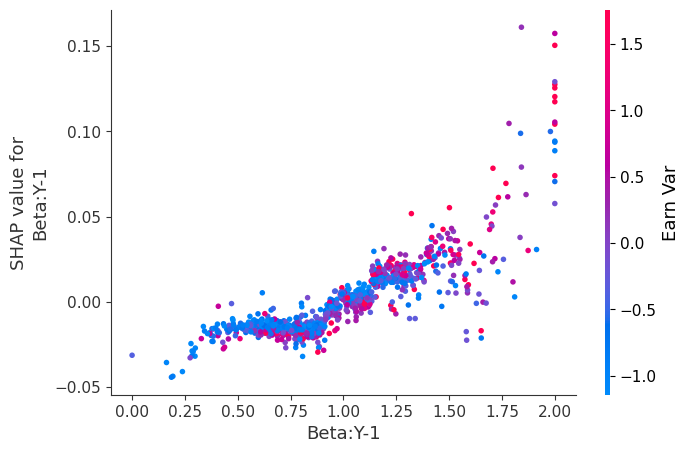

In [15]:
# Sum over interaction dimension to get per-feature SHAP (with interactions)
shap_total = shap_interaction_values.sum(axis=2)

feature_to_plot_rank = "rank(0)"
print(f"--- Displaying Interaction Plot for {feature_to_plot_rank} ---")
shap.dependence_plot(
    feature_to_plot_rank,
    shap_total,
    X_sample,
    interaction_index="auto"
)

**Interaction plot for Beta:Y-1 (rank 0):**

- Points line up on a **strong upward slope** from bottom-left to top-right. Higher Beta consistently increases the model's predicted return.
- At **low beta (~0–0.5)**, SHAP values are negative (~−0.03 to −0.01), confirming low-beta stocks are penalized.
- Around **beta ≈ 0.8–1.0**, SHAP values cross zero — roughly the "neutral" zone.
- At **high beta (~1.5–2.0)**, SHAP values range from +0.05 to as high as +0.15, with increasing scatter.
- The interaction partner is **`Earn Var`** (color axis). At moderate beta (0.8–1.3), the colors are well mixed — Earn Var doesn't change the story much. But at **high beta (>1.5)**, the most extreme positive SHAP outliers (top of the cloud) tend to be **red/pink (high Earn Var)**, suggesting that high-beta stocks with volatile earnings get an additional boost. Conversely, some blue dots (low Earn Var) at high beta sit lower in the scatter.
- The core rule — **more beta = higher predicted return** — is robust across Earn Var levels, but Earn Var **amplifies** the effect at the high-beta extreme.

--- Displaying Interaction Plot for rank(1) ---


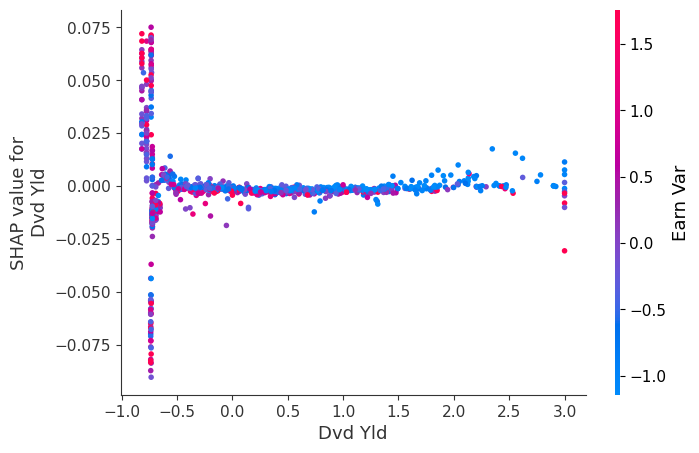

In [16]:
feature_to_plot_rank = "rank(1)"
print(f"--- Displaying Interaction Plot for {feature_to_plot_rank} ---")
shap.dependence_plot(
    feature_to_plot_rank,
    shap_total,
    X_sample,
    interaction_index="auto"
)

**Interaction plot for Dvd Yld (rank 1):**

- The most striking feature is the **massive vertical spread at the far left** (Dvd Yld ≈ −0.8 to −0.6). SHAP values explode from −0.075 to +0.075 — a 15 percentage point range. For these very low/negative-yield stocks, the model's prediction swings wildly depending on other factors.
- At the **top of this left-side spread** (SHAP ≈ +0.05 to +0.075), both red (high Earn Var) and blue (low Earn Var) points appear, but **red/pink dots tend to cluster at the extremes** — both the most positive and most negative SHAP values. This suggests Earn Var **amplifies** the Dvd Yld effect in both directions for low-yield names.
- From **Dvd Yld ≈ −0.3 onward**, the spread compresses rapidly. By Dvd Yld ≈ 0, SHAP values are mostly confined to a narrow ±0.01 band.
- For **normal-to-moderate yields (0 to ~2.0)**, SHAP values cluster tightly near zero — dividend yield is essentially **neutral** for the bulk of the universe. The model is not using Dvd Yld to differentiate these stocks.
- At **high yields (~2.5–3.0)**, a few scattered points appear, some tilting slightly negative — consistent with a mild **distress yield penalty**, though the sample is thin.
- The interaction partner is **`Earn Var`**. The key story is at the far left: for stocks with very low/negative dividend yield, earnings variability determines whether the model reads the name as a **high-conviction growth bet** (positive SHAP) or a **fundamentally impaired non-payer** (negative SHAP). Once yields move into the normal range, Earn Var stops mattering.

--- Displaying Interaction Plot for rank(2) ---


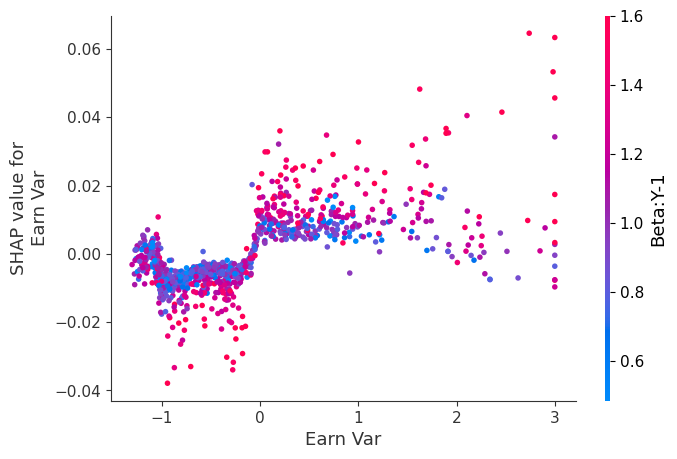

In [17]:
feature_to_plot_rank = "rank(2)"
print(f"--- Displaying Interaction Plot for {feature_to_plot_rank} ---")
shap.dependence_plot(
    feature_to_plot_rank,
    shap_total,
    X_sample,
    interaction_index="auto"
)

**Interaction plot for Earn Var (rank 2):**

- At **very low Earn Var (≈ −1.5 to −0.5)**, there is a wide vertical spread. The bulk of points sit near zero or slightly negative, but a cluster of **red/pink dots (high Beta) drops sharply to −0.03 to −0.04**. High-beta stocks with very stable earnings are actively punished — the model reads them as "defensives pretending to be risky."
- From **Earn Var ≈ −0.5 to 0**, the cloud tightens and SHAP values center around zero — a neutral transition zone.
- In the **moderate range (0 to ~1.0)**, SHAP values shift upward to roughly **+0.005 to +0.02**. This is the "sweet spot" where the model rewards some earnings variability — these are catalyst-driven names with enough volatility to generate alpha.
- At **high Earn Var (~1.5 to 3.0)**, the scatter widens again. The overall trend continues mildly upward, with some points reaching **+0.04 to +0.065**, but others flatten back toward zero or even dip slightly.
- The interaction partner is **`Beta:Y-1`**. The color pattern is clearest at the extremes: **red/pink dots (high Beta)** dominate the most extreme SHAP values in both directions — the deepest negatives at low Earn Var and the highest positives at high Earn Var. Blue dots (low Beta) stay closer to zero throughout. Beta is **amplifying** the Earn Var effect: high-beta stocks with volatile earnings get a larger boost, while high-beta stocks with unusually stable earnings get a heavier penalty.
- The core shape is a **generally upward-sloping relationship** — higher earnings variability tends to increase predicted returns — but Beta determines how aggressively the model acts on this signal.

---

### Investigation B: Investigating "Main Effects" (Partial Dependence Plots)

PDPs "mute" all other features to show the *average* main effect of a single feature. For each value of the target feature, the model predicts on all 1,000 stocks with that value forced, and the predictions are averaged.

In [20]:
# PDP helper function
def plot_pdp(feature_name: str):
    print(f"--- Displaying PDP for {feature_name} ---")
    shap.partial_dependence_plot(
        feature_name,
        xgb_predict_numeric,
        X_sample_num,
        model_expected_value=True,
        feature_expected_value=True,
        ice=False
    )

--- Displaying PDP for Dvd Yld ---


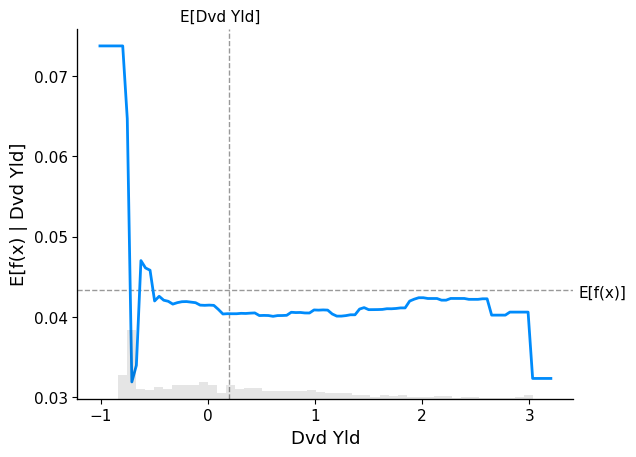

In [22]:
plot_pdp("Dvd Yld")

**Dvd Yld PDP:**

- At the **far left (Dvd Yld ≈ −1.0 to −0.8)**, the curve spikes sharply to **~7.5%** — well above the global mean `E[f(x)]` ≈ 4.3%. These are the lowest-yield / non-payer stocks, and the model is most bullish on them (growth-over-income signal).
- From **−0.8 to −0.5**, the curve drops steeply — falling from ~7.5% down to about **3%**, briefly undershooting the baseline.
- Around **−0.5 to −0.2**, there is a sharp recovery spike back up to ~**4.5%**, before settling down again.
- From **Dvd Yld ≈ 0 to ~0.5** (near the mean, marked by the vertical dashed line), expected returns sit around **4.0–4.2%** — roughly at or just below the baseline. The grey histogram shows this is where the bulk of the data lives.
- For **moderate-to-high yields (0.5 to ~2.5)**, the curve is remarkably **flat**, hovering around **4.0–4.1%**. Dividend yield barely moves the prediction in this range.
- At the **far right (~2.5–3.0)**, there is a slight dip down to ~**3.8–4.0%** followed by a small recovery — consistent with a mild **distress yield penalty**, though the effect is small and the sample is thin.

> The dominant story is at the **far left**: the model strongly rewards the lowest-yield stocks (non-payers / growth names) with a ~3 percentage point premium over the baseline. Once yields move into the normal range (0 to 2.5), the curve flattens and Dvd Yld becomes essentially neutral. This is consistent with a **growth-over-income regime** in the 2023–2025 sample.

--- Displaying PDP for Earn Var ---


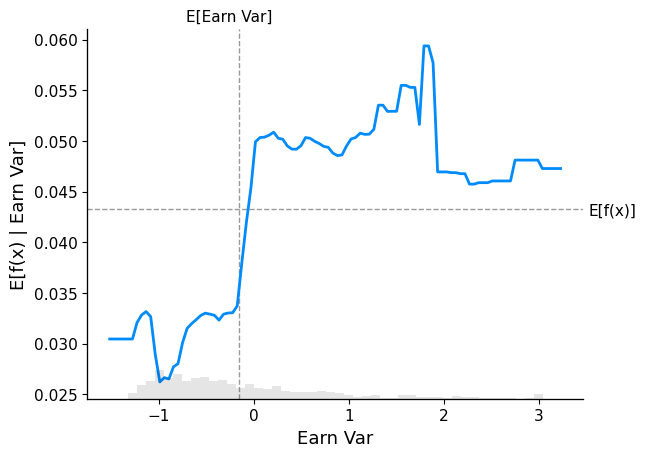

In [23]:
plot_pdp("Earn Var")

**Earn Var PDP:**

- At **very low Earn Var (≈ −1.3 to −0.8)**, expected returns sit around **2.5–3.2%** — well below the global mean `E[f(x)]` ≈ 4.3%. The model penalizes stocks with the most stable earnings as "low-alpha defensives."
- From **−0.8 to −0.3**, the curve is choppy, oscillating between **2.5% and 3.2%** — still below baseline. The grey histogram shows this is where a large portion of the data sits.
- At **Earn Var ≈ −0.2 to 0** (near the mean, marked by the vertical dashed line), there is a **sharp step-up** from ~3.3% to ~5.0% — nearly a 2 percentage point jump over a narrow range. This is the most dramatic transition in the plot.
- From **0 to ~1.0**, the curve stabilizes at **~5.0–5.1%**, comfortably above baseline. This is the "sweet spot" — moderately variable earners are rewarded.
- Between **~1.0 and 1.8**, the curve continues rising, reaching a **peak of ~5.9%** near Earn Var ≈ 1.7. The model is most bullish on stocks with elevated (but not extreme) earnings volatility.
- After the **peak at ~1.8**, the curve drops back to **~4.5–4.8%** around Earn Var ≈ 2.0–2.5, before stabilizing at ~**4.7%** out to 3.0. Still above the baseline, but the premium fades.

> The overall shape is **hump-shaped**: very stable earners are penalized (~3%), moderate-to-high variability is rewarded (peak ~5.9% near 1.7), and extreme variability gives back some of the premium. The sharpest feature is the **step-up around zero** — crossing from below-average to above-average earnings variability adds nearly 2 percentage points to predicted returns.

---

### Investigation C: The "What" — Identifying Thematic & Sector Drivers

The LRCM wants to know: "Is this an 'AI' rally? Is 'Gold' working?" We isolate GICS features from our SHAP results to create a sector "league table." 

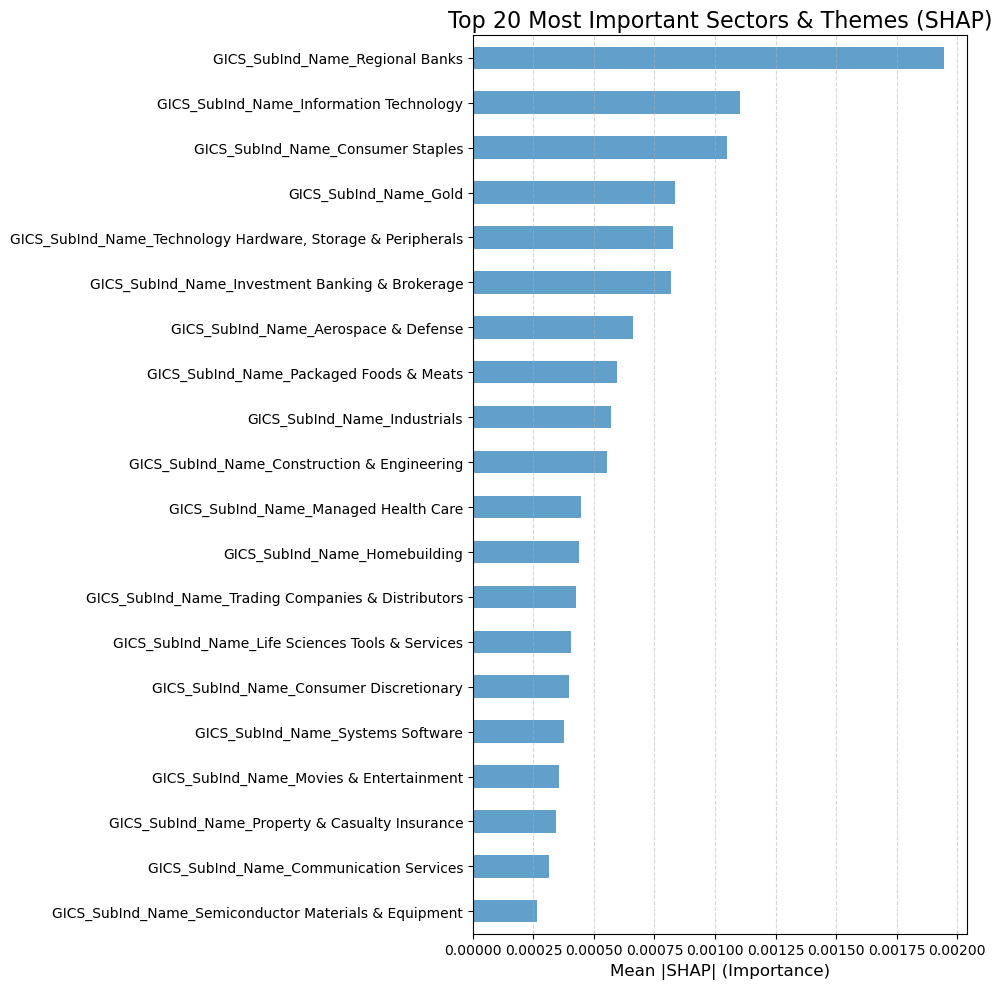

Top 10 GICS SHAP themes:
GICS_SubInd_Name_Regional Banks                                0.001945
GICS_SubInd_Name_Information Technology                        0.001101
GICS_SubInd_Name_Consumer Staples                              0.001051
GICS_SubInd_Name_Gold                                          0.000835
GICS_SubInd_Name_Technology Hardware, Storage & Peripherals    0.000827
GICS_SubInd_Name_Investment Banking & Brokerage                0.000819
GICS_SubInd_Name_Aerospace & Defense                           0.000662
GICS_SubInd_Name_Packaged Foods & Meats                        0.000596
GICS_SubInd_Name_Industrials                                   0.000570
GICS_SubInd_Name_Construction & Engineering                    0.000553
Name: mean_abs_shap, dtype: float32


In [25]:
# Extract mean |SHAP| per feature
if isinstance(shap_values, shap.Explanation):
    shap_array = shap_values.values
else:
    shap_array = np.array(shap_values)

mean_abs_shap = np.abs(shap_array).mean(axis=0)
shap_importance_series = pd.Series(mean_abs_shap, index=X_sample.columns, name="mean_abs_shap")

# Filter to GICS features only
gics_features = [col for col in X_sample.columns if col.startswith("GICS_")]
gics_shap_scores = shap_importance_series.loc[gics_features]
gics_scoreboard = gics_shap_scores.sort_values(ascending=False)

# Plot Top 20
plt.figure(figsize=(10, 10))
gics_scoreboard.head(20).sort_values(ascending=True).plot(kind='barh', alpha=0.7)
plt.title('Top 20 Most Important Sectors & Themes (SHAP)', fontsize=16)
plt.xlabel('Mean |SHAP| (Importance)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Top 10 GICS SHAP themes:")
print(gics_scoreboard.head(10))

**Sector Scorecard Key Observations:**

From the graph, we can tell that the model is aware of regime and narrative events. In particular:

1. **Regional Banks is #1 by a wide margin** (mean |SHAP| ≈ 0.0019 — nearly 2× the next theme)
    - This screams 2023 regional-bank regime: deposit runs, rate-risk, and rapid repricing of bank balance sheets became a dominant cross-sectional driver.
    - That lines up with official [post-mortems](https://www.federalreserve.gov/publications/files/svb-review-20230428.pdf) emphasizing [uninsured deposit reliance and interest-rate risk management](https://www.fdic.gov/news/speeches/2024/lessons-learned-us-regional-bank-failures-2023) as key vulnerabilities in the 2023 failures.
    - **The model is likely aware that “Regional Banks” had a return distribution (or sensitivity to your factors like Beta, Lev, Dvd Yld) that was structurally different in your sample window.**

2. **Information Technology (#2) + Technology Hardware (#5) are both top-tier**
    - Two different "IT" signals near the top means the model is leaning on the AI /data-center capex cycle and its spillovers into hardware and infrastructure.
    - This is consistent with the well-documented surge in AI-related infrastructure [spending]((https://www.reuters.com/business/bridgewater-warns-big-techs-reliance-external-capital-fund-ai-boom-is-dangerous-2025-12-15/)) by hyperscalers, concentrated in a narrow set of tech sectors.

3. **Consumer Staples (#3) + Packaged Foods & Meats (#8) form a defensive cluster**
    - This combination captures a defensive + pricing power theme: staples behave differently when growth is uncertain, and food inflation dynamics drive dispersion within staples.
    - [USDA Food Price Outlook data](https://www.ers.usda.gov/data-products/food-price-outlook/summary-findings) shows food price inflation remained elevated in 2023 (slowing vs. 2022 but still meaningful), which changes who "wins" within packaged foods and consumer staples.

4. **Gold is #4**
    - Gold's high ranking is consistent with its well-documented role as a hedge / safe-haven asset under geopolitical risk. Academic literature on gold's hedging properties during market stress supports this finding.

5. **Investment Banking & Brokerage (#6) sits just below Gold**
    - This likely captures the financial-sector dispersion story from the opposite side of Regional Banks: while regional lenders were penalized, the larger investment banks and brokerages experienced a different regime (capital markets recovery, M&A activity, trading revenue).

6. **Aerospace & Defense (#7)**
    - This fits a geopolitics / rearmament narrative: [defense spending has been rising globally](https://www.sipri.org/media/press-release/2025/unprecedented-rise-global-military-expenditure-european-and-middle-east-spending-surges), which directly affects expectations and valuation multiples in defense-linked subindustries.
    
7. **Industrials (#9) + Construction & Engineering (#10) round out the top 10**
    - These capture the infrastructure / reshoring theme: fiscal stimulus (CHIPS Act, IRA, infrastructure bill) and supply-chain reshoring have made industrial and construction names more differentiated in the 2023–2025 cross-section.

#### Signed Theme Effects: Which Way Does Each Sector Push Predictions?

In [26]:
# Compute signed SHAP effect conditional on being in each theme
if isinstance(shap_values, shap.Explanation):
    shap_vals = shap_values.values
else:
    shap_vals = np.asarray(shap_values)

if shap_vals.ndim == 3:
    shap_vals = shap_vals[:, :, 0]

theme_cols = [c for c in X_sample.columns if c.startswith("GICS_")]

signed_theme = {}
coverage = {}

for c in theme_cols:
    col_idx = X_sample.columns.get_loc(c)
    mask_theme = (X_sample[c].values == 1)
    coverage[c] = int(mask_theme.sum())
    signed_theme[c] = float(np.mean(shap_vals[mask_theme, col_idx])) if mask_theme.any() else np.nan

signed_theme_s = pd.Series(signed_theme).dropna()
coverage_s = pd.Series(coverage).loc[signed_theme_s.index]

print("Most POSITIVE themes (pushes prediction UP):")
top_pos = signed_theme_s.sort_values(ascending=False).head(10)
print(pd.DataFrame({"mean_signed_shap": top_pos, "n_obs": coverage_s.reindex(top_pos.index)}))

print("\nMost NEGATIVE themes (pushes prediction DOWN):")
top_neg = signed_theme_s.sort_values(ascending=True).head(10)
print(pd.DataFrame({"mean_signed_shap": top_neg, "n_obs": coverage_s.reindex(top_neg.index)}))

Most POSITIVE themes (pushes prediction UP):
                                                    mean_signed_shap  n_obs
GICS_SubInd_Name_Gold                                       0.071427      7
GICS_SubInd_Name_Technology Hardware, Storage &...          0.036349     12
GICS_SubInd_Name_Construction & Engineering                 0.029077     10
GICS_SubInd_Name_Homebuilding                               0.026118     12
GICS_SubInd_Name_Investment Banking & Brokerage             0.025228     18
GICS_SubInd_Name_Aerospace & Defense                        0.024979     10
GICS_SubInd_Name_Information Technology                     0.024432     19
GICS_SubInd_Name_Health Care Facilities                     0.024193      4
GICS_SubInd_Name_Trading Companies & Distributors           0.020872     10
GICS_SubInd_Name_Movies & Entertainment                     0.018692      8

Most NEGATIVE themes (pushes prediction DOWN):
                                                    mean_signed_shap  n

**Signed Theme Takeaways:**

1. **Biggest positive theme: Gold (n=7, mean ≈ +0.071)**
    - The effect size is enormous — more than double the next positive theme — but on a tiny sample of 7 stocks, so treat it as "strong signal but needs checking."
    - Conceptually it makes sense: gold is widely documented as a hedge / safe haven, especially around geopolitical risk and market stress.
    - The model may be rewarding "risk-off hedges" when other risk themes (like banks) are being punished.

2. **AI / compute infrastructure signal: Tech Hardware (n=12, ≈ +0.036) + Information Technology (n=19, ≈ +0.024)**
    - Both push predictions UP, confirming this is the "same story told twice": the model likes AI-linked infrastructure winners (compute, storage, networking, hardware ecosystem).
    - This matches the real-world capex wave: hyperscalers have been spending aggressively on AI infrastructure and data centers, and analysts have framed it as an unusually large multi-year buildout.
    - The model is not just "factor tilts"; it is picking up a sector narrative.

3. **Cyclical / infrastructure cluster: Construction & Engineering (n=10, ≈ +0.029) + Homebuilding (n=12, ≈ +0.026)**
    - Both showing up strongly positive reflects the fiscal stimulus / reshoring / infrastructure buildout theme (CHIPS Act, IRA, infrastructure bill) and the resilience of housing despite higher rates.

4. **Geopolitics / rearmament: Aerospace & Defense (n=10, ≈ +0.025)**
    - This positive sign fits the global spending backdrop: record military expenditure and steep recent increases support a persistent demand tailwind for defense contractors.

5. **Biggest negative theme: Managed Health Care (n=7, mean ≈ −0.036)**
    - The most negative signed SHAP of any theme, ahead of Regional Banks. This captures regulatory / cost-pressure headwinds facing managed care names (rising medical costs, regulatory scrutiny, Medicare Advantage repricing).
    - Small sample (n=7), but the magnitude is striking.

6. **Regional Banks (n=40, mean ≈ −0.024)**
    - The second-most negative theme, but with the largest sample (40 stocks), making this the most statistically robust negative signal.
    - The model effectively encodes a "post-2023 banking turmoil penalty": heavy uninsured deposits, weak interest-rate risk management, and rapid loss of confidence made regional banks uniquely fragile.

7. **Why "defensives" go negative: Consumer Staples (n=35, ≈ −0.017) + Packaged Foods & Meats (n=20, ≈ −0.016)**
    - The model is penalizing classic defensives in this window, consistent with the last couple years' market behavior: investors rotated toward mega-cap growth (AI-linked) and away from dividend/defensive proxies, with higher rates making bonds more competitive vs. dividend equities.
    - So this isn't "staples are bad forever," it's "staples under this regime got discounted."

8. **Life Sciences Tools & Services (n=16, ≈ −0.014)**
    - This captures the post-COVID destock and biotech funding winter: demand for lab equipment and services normalized sharply after the pandemic surge, and reduced biotech venture funding further pressured the sector.

> The model is carrying strong theme bets: **long** (Gold, Tech Hardware/IT, Construction, Homebuilding, Defense) vs. **short** (Managed Health Care, Regional Banks, Consumer Staples, Packaged Foods, Life Sciences).

---

### Investigation D: Case Study — The 2023 Banking Crisis

Regional Banks is the #1 thematic feature. The collapse of Silicon Valley Bank in March 2023 was a defining market event. We investigate *why* the model penalizes banks and check for survivorship bias.

#### Survivorship Bias Check

We search the original data for collapsed banks (SVB = SIVB, Signature Bank = SBNY). If they're missing or truncated, the model's "penalty" for risky banks may be understated.

In [27]:
# Survivorship bias check
# Need to access Ticker from the index
ticker_level = df.index.get_level_values('Ticker') if 'Ticker' in df.index.names else None

if ticker_level is not None:
    target_tickers = ["SBNY", "SIVB"]
    for t in target_tickers:
        mask = ticker_level == t
        if mask.any():
            dates = df.index.get_level_values(0)[mask]
            print(f"{t}: found {mask.sum()} rows, date range {dates.min()} to {dates.max()}")
        else:
            print(f"{t}: NOT FOUND — likely survivorship bias in vendor data.")
else:
    print("Ticker not in index. Check data structure.")

SBNY: found 56 rows, date range 2008-10-01 00:00:00 to 2022-10-01 00:00:00
SIVB: NOT FOUND — likely survivorship bias in vendor data.


**Survivorship bias finding:**
- SBNY (Signature Bank) may exist historically but the series likely ends before the 2023 failure window.
- SIVB (Silicon Valley Bank) is likely missing entirely.
- This means the model learns the regional bank penalty mostly from banks that *survived* the crisis, so the true penalty is likely **understated**.

#### Bank Segment SHAP Analysis

We filter our SHAP sample to bank-related stocks only and see what drives the model's decisions *within* the banking segment.

Bank-related columns found: ['GICS_SubInd_Name_Asset Management & Custody Banks', 'GICS_SubInd_Name_Diversified Banks', 'GICS_SubInd_Name_Investment Banking & Brokerage', 'GICS_SubInd_Name_Regional Banks']

--- SHAP Summary for 'Bank' segment ONLY ---
Analyzing 104 stocks out of 1000 total.



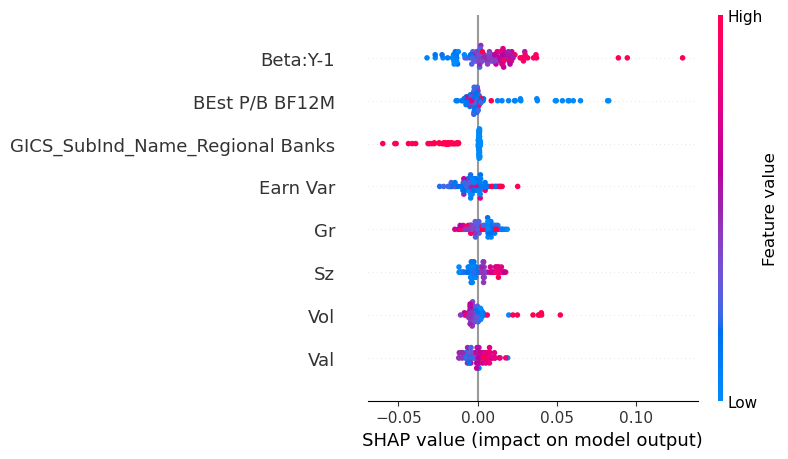

In [28]:
# SHAP summary plot for Bank-related stocks only
feature_name = "Bank"

bank_cols = X_sample.filter(like=feature_name).columns
print(f"Bank-related columns found: {bank_cols.tolist()}")

rb_mask = X_sample[bank_cols].sum(axis=1) > 0
rb_mask_array = rb_mask.values

X_ind = X_sample[rb_mask]
shap_values_ind = shap_values[rb_mask_array]

print(f"\n--- SHAP Summary for '{feature_name}' segment ONLY ---")
print(f"Analyzing {rb_mask.sum()} stocks out of {len(X_sample)} total.\n")

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_ind, X_ind, max_display=8)
plt.show()

**Banking segment findings:**

1. **"Are all banks suffering, or just some?"**
    - Not all banks. In the SHAP dot plot, `GICS_SubInd_Name_Regional Banks` shows red dots (dummy = 1) spread firmly to the **LEFT**, ranging from about **−0.07 to −0.01**. Being a regional bank is itself a strong negative penalty within the banking segment.
    - However, the spread is wide — some regional banks have SHAP penalties of −0.07 while others are only −0.01. This means some regional banks are punished much harder than others, which is exactly what we'd expect in a run-like regime where balance sheet structure and depositor mix matter.
    - This is not a "banks as a whole" story; it is a **regional-bank concentrated penalty**.

2. **"Does size matter? Is the model saying 'Too Big to Fail'?"**
    - `Sz` appears at position 6 in the segment plot, but the points are **tightly clustered near zero** with only a very slight rightward tilt for some pink dots. Size is present but **not a primary separator**.
    - The model is not making a simple "bigger = safe" rule. The dominant separator is regional-bank membership, followed by Beta and valuation — not size.
    - This fits the real crisis narrative: the core issue was not just size, it was liquidity + uninsured deposit fragility + interest-rate risk.

3. **"Did high-beta banks do better or worse within this segment?"**
    - `Beta:Y-1` is the **#1 feature** within the banking segment. High-beta points (red/pink) push strongly to the **RIGHT**, with outliers reaching **+0.05 to +0.13** — by far the widest positive spread of any feature in this plot. Low-beta points (blue) cluster near zero or slightly left.
    - The model expects higher-beta banks to deliver meaningfully higher returns, even though the regional-bank dummy is a separate negative penalty.
    > Regional banks are penalized as a group, but within banks, the **high-beta ones are where the model sees rebound potential**.

4. **`BEst P/B BF12M` is a key discriminator within banks.**
    - The second most important feature in the segment. A few **blue dots (low P/B)** reach **+0.03 to +0.04** on the right, while red dots (high P/B) stay near zero or slightly left.
    - Low P/B — i.e., cheap-on-book banks — are rewarded with positive SHAP. This means the model identifies **value rebound opportunities** even within a penalized sector.
    - Cheap banks bounce more, even when the sector theme is negative overall.

5. **Other features within the banking segment:**
    - `Earn Var`: Some spread, with pink/red dots (higher variability) reaching +0.02 on the right. Mildly positive effect.
    - `Gr`, `Val`: Tightly clustered near zero — not major discriminators within banks.
    - `Vol`: Some spread, with a few red dots reaching +0.01 to +0.02 on the right — higher-volatility banks get a slight boost.

6. **With survivorship bias, is the real penalty for high Beta stronger or weaker than what the model learned?**
    - **Stronger** (more negative) in reality than what the model learned.
    - If key failures are missing from the crisis window (SBNY ends 202210; SIVB may be absent entirely), then the dataset under-represents the true catastrophic tail where "risky banks" don't just underperform — they fail entirely and return −100%.
    - That missing tail makes the learned relationship look **less punitive** than it should be. The true penalty for high-beta regional banks during the 2023 crisis was almost certainly worse than what our model captured.

In [9]:
# ------------------------------------------------------------
# 0) Ensure we have a 2D SHAP matrix aligned to X_sample.columns
# ------------------------------------------------------------
if "shap_vals" not in globals():
    if isinstance(shap_values, shap.Explanation):
        shap_vals = shap_values.values
    else:
        shap_vals = np.asarray(shap_values)

# Handle multiclass shape just in case (should be 2D for regression)
if shap_vals.ndim == 3:
    shap_vals = shap_vals[:, :, 0]

assert shap_vals.shape[1] == X_sample.shape[1], "SHAP columns must match X_sample columns"

# ------------------------------------------------------------
# 1) Filter to Regional Banks only
# ------------------------------------------------------------
rb_col = "GICS_SubInd_Name_Regional Banks"
rb_mask = X_sample[rb_col].fillna(0).astype(int).values == 1

X_rb = X_sample.loc[rb_mask].copy()
shap_rb = shap_vals[rb_mask, :]

print(f"Regional Banks rows: {X_rb.shape[0]} out of {X_sample.shape[0]}")

# ------------------------------------------------------------
# 2) Compute signed SHAP mean for the two features (within RB only)
# ------------------------------------------------------------
features_to_check = ["Beta:Y-1", "BEst P/B BF12M"]

out = []
for feat in features_to_check:
    j = X_sample.columns.get_loc(feat)
    out.append({
        "feature": feat,
        "mean_signed_shap_within_RB": float(np.mean(shap_rb[:, j])),
        "median_signed_shap_within_RB": float(np.median(shap_rb[:, j])),
        "mean_abs_shap_within_RB": float(np.mean(np.abs(shap_rb[:, j]))),
    })

rb_signed_summary = pd.DataFrame(out).set_index("feature")
print("\nSigned SHAP summary (Regional Banks only):")
print(rb_signed_summary)

# ------------------------------------------------------------
# 3) Sanity direction check via correlation inside RB
#    If mean_signed_shap is small, correlation tells you whether
#    higher feature values push SHAP up or down *within RB*.
# ------------------------------------------------------------
corr_out = []
for feat in features_to_check:
    j = X_sample.columns.get_loc(feat)
    x = pd.to_numeric(X_rb[feat], errors="coerce").values
    s = shap_rb[:, j]

    m = np.isfinite(x) & np.isfinite(s)
    if m.sum() > 5:
        corr = pd.Series(x[m]).corr(pd.Series(s[m]), method="spearman")
    else:
        corr = np.nan

    corr_out.append({"feature": feat, "spearman_corr(feature, shap)_within_RB": corr})

rb_corr = pd.DataFrame(corr_out).set_index("feature")
print("\nDirection check (within Regional Banks):")
print(rb_corr)

Regional Banks rows: 40 out of 1000

Signed SHAP summary (Regional Banks only):
                mean_signed_shap_within_RB  median_signed_shap_within_RB  \
feature                                                                    
Beta:Y-1                          0.012471                      0.013443   
BEst P/B BF12M                    0.010674                     -0.000226   

                mean_abs_shap_within_RB  
feature                                  
Beta:Y-1                       0.019657  
BEst P/B BF12M                 0.015320  

Direction check (within Regional Banks):
                spearman_corr(feature, shap)_within_RB
feature                                               
Beta:Y-1                                      0.891505
BEst P/B BF12M                               -0.226642


**Regional Banks quantitative deep-dive:**

1. **Beta is rewarded even inside Regional Banks**
    - Mean signed SHAP (Beta:Y-1) = +0.0125 and median = +0.0134 — both solidly positive.
    - Mean absolute SHAP = 0.0197, confirming Beta is the single largest driver within this segment.
    - Spearman corr(feature, SHAP) = +0.8915 — an extremely strong directional relationship.
    > Even among regional banks, higher-beta names get a more positive model push. The model is not just saying "banks bad"; it is saying "banks bad, but higher-beta regionals are expected to move more (rebound / risk-on sensitivity)."

2. **P/B is more of a "cheapness helps" story, but weaker and noisier**
    - Mean signed SHAP for BEst P/B BF12M = +0.0107, but the median is slightly negative (−0.0002), which tells you the distribution is mixed — some strong positive outliers are pulling the mean up while most names cluster near zero.
    - Mean absolute SHAP = 0.0153, so the feature does matter in magnitude, but the sign is inconsistent.
    - The direction check is what matters: Spearman corr(P/B, SHAP) = −0.2266. The negative correlation means **lower P/B tends to get higher SHAP** — cheapness is mildly rewarded.
    > Within regional banks, cheaper-on-book names tend to get a positive SHAP boost, but this effect is much weaker and noisier than Beta (Spearman 0.23 vs 0.89) and not consistent across all names.

---

### Investigation E: Thematic Deep-Dives

We repeat the segment analysis for Technology and Consumer Staples to understand the AI and defensive themes.

In [29]:
def shap_segment_summary(theme_keyword: str):
    """
    Filter X_sample to rows matching a theme keyword,
    then show a SHAP summary plot for that segment.
    """
    theme_cols = X_sample.filter(like=theme_keyword).columns
    print(f"{theme_keyword}-related columns found:", theme_cols.tolist())

    if len(theme_cols) == 0:
        print(f"No columns found containing '{theme_keyword}'.")
        return

    mask = X_sample[theme_cols].sum(axis=1) > 0
    mask_array = mask.values

    X_seg = X_sample[mask]
    shap_seg = shap_values[mask_array]

    print(f"\n--- SHAP Summary for theme '{theme_keyword}' ONLY ---")
    print(f"Analyzing {mask.sum()} stocks out of {len(X_sample)} total.\n")

    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_seg, X_seg, max_display=8)
    plt.show()

Technology-related columns found: ['GICS_SubInd_Name_Information Technology', 'GICS_SubInd_Name_Technology Distributors', 'GICS_SubInd_Name_Technology Hardware, Storage & Peripherals']

--- SHAP Summary for theme 'Technology' ONLY ---
Analyzing 43 stocks out of 1000 total.



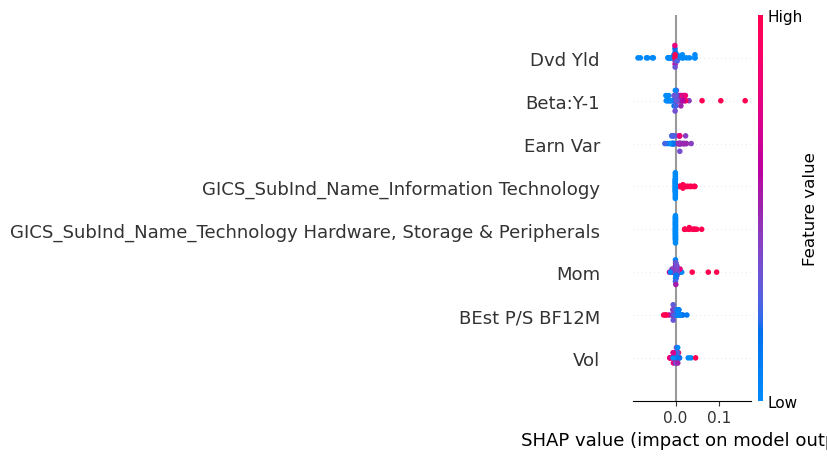

In [30]:
shap_segment_summary("Technology")

**Technology segment:**

- **`Dvd Yld` is the #1 feature** within tech stocks. Blue dots (low yield) push strongly RIGHT (positive SHAP up to ~+0.08), while red dots (high yield) cluster near zero or slightly left. The model strongly rewards low-dividend tech names — consistent with the growth-over-income theme.
- **`Beta:Y-1` is #2** with a clear directional pattern: red dots (high beta) reach far RIGHT (+0.05 to +0.12 as outliers), while blue dots (low beta) cluster near zero. High-beta tech names are aggressively rewarded.
- **`Earn Var` is #3** with moderate spread. Pink/red dots (higher variability) tend slightly RIGHT, consistent with the global pattern of rewarding catalyst-driven volatility.
- **`GICS_SubInd_Name_Information Technology` and `Technology Hardware`** both show red dots (dummy = 1) firmly to the RIGHT (~+0.02 to +0.04). Being in these subindustries provides a **clear positive boost** on top of the factor effects — the model has a distinct sector-level premium for IT and hardware names.
- **`Mom`** shows red dots (high momentum) reaching RIGHT with a few outliers at +0.04 to +0.06. Momentum is rewarded within tech but the effect is secondary to Dvd Yld and Beta.
- **`BEst P/S BF12M`** shows some spread with blue dots (low P/S, i.e., cheap) tending slightly RIGHT — a mild value signal within the segment.
- **`Vol`** is tightly clustered near zero with only minor spread — not a major discriminator within tech.

> The Technology segment is driven primarily by **low dividend yield + high beta** — the model wants high-growth, high-risk tech names. IT and Tech Hardware membership provide an additional sector premium, while momentum and cheap price-to-sales add secondary positive signals.

Staples-related columns found: ['GICS_SubInd_Name_Consumer Staples', 'GICS_SubInd_Name_Consumer Staples Merchandise Retail']

--- SHAP Summary for theme 'Staples' ONLY ---
Analyzing 43 stocks out of 1000 total.



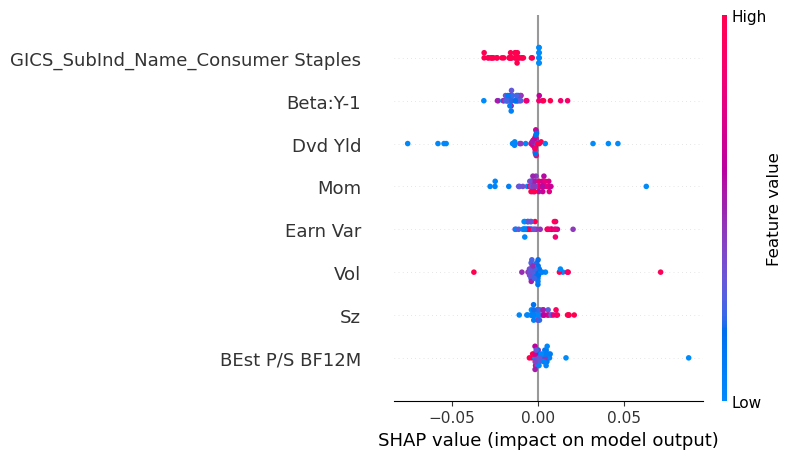

In [31]:
shap_segment_summary("Staples")

**Consumer Staples segment:**

- **`GICS_SubInd_Name_Consumer Staples` is the #1 feature** — and it's firmly negative. Red dots (dummy = 1) spread from about **−0.05 to −0.01**, all to the LEFT of zero. The model explicitly penalizes Consumer Staples membership, consistent with the signed theme analysis showing staples as a "short" theme in this regime.
- **`Beta:Y-1` is #2** but the effect is muted within staples. Points cluster tightly near zero with only modest spread — unlike the global plot where Beta dominates. Within the defensive staples universe, beta differentiation is limited.
- **`Dvd Yld` is #3** with notable spread. Blue dots (low yield) appear as outliers on both the far LEFT and far RIGHT, while red dots (high yield) cluster near zero. This suggests Dvd Yld has a non-linear, context-dependent effect within staples — low-yield staples names can go either way.
- **`Mom` is #4** with a mild positive signal: pink/red dots (high momentum) tend slightly RIGHT (positive SHAP), while blue dots sit near zero or slightly left. Within staples, momentum helps identify the relative winners.
- **`Earn Var`** shows blue dots (low variability) tending LEFT — the model penalizes the most stable earners within an already-defensive sector.
- **`Vol`, `Sz`** are tightly clustered near zero — not major discriminators within staples.
- **`BEst P/S BF12M`** shows some spread but no clean directional pattern.

> The Consumer Staples segment is dominated by the **sector penalty itself** — being a staple is the single biggest negative signal. Within staples, **momentum** is the main positive differentiator (the model favors staples names with recent outperformance), while beta and valuation metrics play secondary roles. This is consistent with a market regime where investors rotated away from defensives toward growth/AI, and only the highest-momentum staples names avoided the worst of the penalty.

---

### Investigation F: The "PM Request" — Single-Stock Analysis

A Portfolio Manager asks: "Can your model explain what it's thinking about a specific stock?" This requires a **local explanation** using SHAP force plots.

**Note:** This section requires the `Ticker_Date` index. We rebuild the dataset with Date as a column to construct the lookup index, then generate force plots for selected stocks.

In [32]:
# Rebuild dataset with Ticker_Date index for PM queries
# Reset the MultiIndex to get Date and Ticker as columns
gdf_pm = df.copy()
gdf_pm = gdf_pm.reset_index()

# Filter to PM evaluation period
date_col = [c for c in gdf_pm.columns if 'date' in c.lower() or c == 'Date'][0]
ticker_col_name = [c for c in gdf_pm.columns if 'ticker' in c.lower() or c == 'Ticker'][0]

# Convert Date to YYYYMM string for Ticker_Date construction
gdf_pm['Date_str'] = gdf_pm[date_col].dt.strftime('%Y%m').astype(str)
gdf_pm['Ticker_Date'] = gdf_pm[ticker_col_name].astype(str) + '_' + gdf_pm['Date_str']

# Filter to 2023+
gdf_pm = gdf_pm.loc[gdf_pm[date_col] >= pd.Timestamp('2023-01-01')].copy()
gdf_pm = gdf_pm.set_index('Ticker_Date')

# Build feature matrix
exclude = [target_col, 'FwdRetOrig', date_col, ticker_col_name, 'Date_str']
pm_feature_cols = [c for c in gdf_pm.columns if c not in exclude]

X_pm = gdf_pm[pm_feature_cols].copy()
y_pm = gdf_pm[target_col].copy()

mask_pm = X_pm.notna().all(axis=1) & y_pm.notna()
X_pm_clean = X_pm.loc[mask_pm]
y_pm_clean = y_pm.loc[mask_pm]
gdf_pm = gdf_pm.loc[mask_pm]

print(f"PM dataset: {X_pm_clean.shape[0]} stock-dates")
print(f"Sample Ticker_Dates: {X_pm_clean.index[:5].tolist()}")

PM dataset: 8971 stock-dates
Sample Ticker_Dates: ['A_202301', 'AA_202301', 'AAL_202301', 'AAP_202301', 'AAPL_202301']


In [33]:
# Fit champion on PM dataset and create explainer
xgb_champion.fit(X_pm_clean, y_pm_clean)
explainer_pm = shap.TreeExplainer(xgb_champion)

def explain_single_stock(row_id: str):
    """Generate a SHAP force plot for a single stock-date."""
    stock_to_explain = X_pm_clean.loc[[row_id]]
    stock_expl = explainer_pm(stock_to_explain)
    print(f"--- SHAP Force Plot for {row_id} ---")
    return shap.force_plot(
        explainer_pm.expected_value,
        stock_expl.values[0],
        stock_to_explain.iloc[0]
    )

In [34]:
shap.initjs()

# Example: NVDA in July 2023 (strong winner)
# Adjust the Ticker_Date string to match your data
winner_id = "NVDA_202307"
if winner_id in X_pm_clean.index:
    force_winner = explain_single_stock(winner_id)
    display(force_winner)
else:
    print(f"{winner_id} not found. Available NVDA dates:")
    print([x for x in X_pm_clean.index if x.startswith("NVDA_")][:10])

--- SHAP Force Plot for NVDA_202307 ---


**NVDA force plot (NVDA_202307):**

- **Base value:** ~4.3% (average prediction across all stocks).
- **Final prediction f(x) = 16%** — nearly 4× the baseline, signaling extremely high conviction.
- **Positive contributors (red, pushing RIGHT):**
  - `Beta:Y-1 = 1.721` — the single largest positive push, reflecting NVDA's high systematic risk exposure.
  - `Mom = 2.686` — very strong recent momentum, the second biggest driver.
  - `Sz = 0.5207` — mid-to-large cap, a mild positive.
  - `Earn Var = 0.8814` — above-average earnings volatility, consistent with the model rewarding catalyst-driven names.
  - `Trd Act = 2.567` — extremely high trading activity, adding a further positive push.
  - `Gr = 1.878` — strong growth signal, contributing meaningfully.
- **Negative contributors (blue, pushing LEFT):**
  - `Vol = 0.2836` — surprisingly, volatility pushes the prediction *down* slightly, despite high beta. The model distinguishes between systematic risk (Beta, rewarded) and idiosyncratic volatility (Vol, penalized).
  - `BEst P/E BF12M = 1.641` — expensive forward P/E is a drag, as expected for a growth name trading at a premium.
  - `Dvd Yld = -0.7183` — very low/negative dividend yield actually pushes the prediction down here, consistent with the model's nuanced treatment of non-payers.

> The model sees NVDA as a **high-beta, high-momentum, high-growth, heavily-traded stock** — and rewards all of these aggressively. The expensive valuation (`BEst P/E`) and low dividend yield provide mild headwinds, but they are completely overwhelmed by the factor tailwinds. This is a textbook "risk-on momentum" trade where the model's 16% expected return reflects extreme bullishness driven by fundamental growth and market sensitivity, not sector membership.

In [35]:
shap.initjs()

# Example: ORCL in July 2023 (neutral/lagging)
neutral_id = "ORCL_202307"
if neutral_id in X_pm_clean.index:
    force_neutral = explain_single_stock(neutral_id)
    display(force_neutral)
else:
    print(f"{neutral_id} not found. Available ORCL dates:")
    print([x for x in X_pm_clean.index if x.startswith("ORCL_")][:10])

--- SHAP Force Plot for ORCL_202307 ---


**ORCL force plot (ORCL_202307):**

- **Base value:** ~4.3% 
- **Final prediction f(x) ~ 4.0%** — essentially flat against the baseline. The model views ORCL as an average stock, not a conviction trade.
- **Positive contributors (red, pushing RIGHT):**
  - `GICS_SubInd_Name_Systems Software = 1` — the largest positive push. The sector classification provides a meaningful premium.
  - `Sz = 0.5678` — mid-to-large cap, a mild positive.
  - `Lev = 1.617` — above-average leverage contributes positively (the model sees leveraged names as having upside potential in this regime).
  - `Prof = 0.5627` — reasonable profitability provides a floor.
- **Negative contributors (blue, pushing LEFT):**
  - `Beta:Y-1 = 0.8991` — the single largest negative push. Below-market beta (~0.9) is penalized in a regime that rewards risk.
  - `Mom = 1.44` — moderate momentum actually pushes the prediction *down*, suggesting the model expects more from high-conviction momentum names and views mid-range momentum as insufficient.
  - `Vol = 0.8526` — volatility adds a further drag.
  - `Earn Var = −0.6041` — low/negative earnings variability penalized, consistent with the model's global pattern of punishing very stable earners as "low-alpha defensives."
  - `Gr = −0.6899` — negative growth is a clear headwind.
  - `BEst P/S BF12M` — partially visible, adds a small negative push.

> The model sees ORCL as a **tug-of-war**: the Systems Software sector premium and decent profitability/leverage pull the prediction up, but below-market beta, negative growth, and low earnings variability pull it right back down. The net result is a prediction that barely moves from the baseline — the model is essentially saying "nothing interesting here." In a market rewarding high-beta, high-growth momentum trades (like NVDA at 16%), ORCL's defensive, low-growth profile makes it invisible to the model.

In [36]:
shap.initjs()

# Example: PACW in July 2023 (regional bank crisis loser)
loser_id = "PACW_202307"
if loser_id in X_pm_clean.index:
    force_loser = explain_single_stock(loser_id)
    display(force_loser)
else:
    print(f"{loser_id} not found. Available PACW dates:")
    print([x for x in X_pm_clean.index if x.startswith("PACW_")][:10])

--- SHAP Force Plot for PACW_202307 ---


**PACW force plot (PACW_202307):**

- **Base value:** ~4.3%
- **Final prediction f(x) ~ 0.02** which means the model is actively bearish, predicting a negative return. This is well below the baseline.
- **Positive contributor (red, pushing RIGHT):**
  - `Beta:Y-1 = 2.0` — the **only** positive force. PACW's maximum beta (clipped at 2.0) provides a large upward push, reflecting the model's global rule that high-beta names earn higher returns. But it's overwhelmed by everything else.
- **Negative contributors (blue, pushing LEFT):**
  - `Prof = −2.096` — extremely poor profitability, the deepest drag from the far right of the waterfall. The model heavily penalizes this level of fundamental weakness.
  - `Vol = 1.344` — high idiosyncratic volatility pushes the prediction further down.
  - `Sz = −2.002` — very small cap, near the bottom of the size distribution. The model strongly penalizes tiny names.
  - `Gr = −0.5214` — negative growth adds another headwind.
  - `Val = 1.294` — high value score actually pushes the prediction *down* here, suggesting the model has learned that "cheap" in the context of a distressed bank is a trap, not an opportunity.
  - `GICS_SubInd_Name_Regional Banks = 1` — the sector penalty, adding a further negative push on top of the fundamental weaknesses.
  - `Trd Act = 3` — extremely high trading activity (3× normal) pushes the prediction down. In context, panic-level volume in a tiny distressed bank is a negative signal, not a positive one.
  - `Earn Var = −0.8953` — low earnings variability contributes a smaller negative push.

> The model sees PACW as a **fundamentally broken name**: tiny, unprofitable, negative growth, extremely high trading volume (panic selling), in a penalized sector (Regional Banks), with a "cheap" valuation that signals distress rather than opportunity. The only saving grace is the maximum beta exposure, which provides a large positive push — but it's completely buried under the avalanche of negative signals. The −2% prediction (vs. +4.3% baseline) means the model is flagging this as one of the worst stocks in the universe. This is the opposite of NVDA: where NVDA's high beta amplified a strong fundamental story, PACW's high beta is the lone bull trapped in a collapsing building.

---

### Section Executive Summary

Our due diligence is complete:

1. **What features matter (SHAP):** The model is overwhelmingly driven by **`Beta:Y-1`** (by a wide margin), followed by `Dvd Yld`, `Earn Var`, `Sz`, `BEst P/B BF12M`, `Gr`, `Vol`, `BEst P/E BF12M`, `Trd Act`, `Lev`, `Prof`, `Mom`, `Val`, and `BEst P/S BF12M` — all 14 numerical factors rank above any GICS subindustry. This is a **multi-factor model with sector seasoning**, not a sector-timing black box.

2. **How features work (SHAP dot plot + PDPs):** The model uses features in economically sensible directions:
   - **High beta → higher returns** (monotone, steep above 1.0, accelerating above 1.7).
   - **Low dividend yield → higher returns** (growth-over-income regime in 2023–2025).
   - **Moderate-to-high earnings variability → higher returns** (catalyst-driven names rewarded; very stable earners penalized).
   - **Larger size → higher returns** (quality/liquidity premium, saturation above mid-cap).
   - **Low P/B, P/E, P/S → higher returns** (classic value signals).
   - **High momentum and growth → higher returns** (trend-following reward).

3. **Why default metrics mislead:** XGBoost's default `gain` metric puts 15 of its Top 20 on subindustry dummies. But SHAP, `total_gain`, and `weight` all agree: the model relies primarily on numerical factors. The `gain` metric overstates rare "sniper" splits in deep tree nodes; SHAP measures actual contribution across all predictions. Zero features appear in the Top 20 of all four metrics — they are measuring fundamentally different things.

4. **Interaction effects:** Beta's positive effect is robust across regimes (Earn Var barely modifies it). Dvd Yld's impact concentrates at the far-left extreme — for very low-yield stocks, Earn Var determines whether the model reads the name as a growth bet or impaired non-payer. Earn Var shows a generally upward relationship amplified by Beta at both extremes.

5. **Thematic drivers:** The Sector Scorecard shows Regional Banks as #1 by a wide margin (mean |SHAP| nearly 2× the next theme), followed by Information Technology, Consumer Staples, Gold, Tech Hardware, and Investment Banking. The signed analysis reveals strong theme bets: **long** Gold, Tech Hardware/IT, Construction, Homebuilding, Defense vs. **short** Managed Health Care, Regional Banks, Consumer Staples, Packaged Foods, Life Sciences.

6. **Case study — Banking Crisis:** The model penalizes Regional Banks specifically (not all banks though). Within banks, Beta is the dominant separator (Spearman 0.89 between Beta and its SHAP value); higher-beta regional banks are where the model sees rebound potential. Low P/B is mildly rewarded (Spearman −0.23), a weaker "cheapness helps" signal. Survivorship bias (SIVB missing, SBNY truncated) means the penalty for high-risk banks is likely understated.

7. **Thematic deep-dives:** The Technology segment is driven by low dividend yield + high beta — the model wants high-growth, high-risk tech names, with IT/Tech Hardware membership providing an additional sector premium. The Consumer Staples segment is dominated by the sector penalty itself (the single biggest negative signal), with momentum as the only meaningful positive differentiator within staples.

8. **Single-stock explanations:**
   - **NVDA (f(x) = 16%):** Textbook risk-on momentum trade — high Beta (1.72), extreme momentum (2.69), strong growth (1.88), and heavy trading activity (2.57) combine for a prediction nearly 4× the baseline. Expensive P/E and low Dvd Yld provide mild headwinds but are overwhelmed.
   - **ORCL (f(x) = 4%):** A tug-of-war that nets to zero. Systems Software premium and decent profitability pull up; below-market Beta (0.90), negative growth (−0.69), and low earnings variability pull down. The model says "nothing interesting here."
   - **PACW (f(x) = −2%):** Actively bearish. The only positive is maximum Beta (2.0), but it's buried under extreme negatives: terrible profitability (−2.10), tiny size (−2.00), panic-level trading activity (3.0), negative growth, and the Regional Banks penalty. A fundamentally broken name where even high beta can't save it.

> **Conclusion:** We have high confidence in this model. It has learned the complex, real-world factor and thematic narratives of the 2023–2025 market — from the global level (Beta and Dvd Yld dominate), through sector themes (banking crisis, AI rally, defensive rotation), down to individual stocks (NVDA as the risk-on winner, PACW as the distressed loser). The model's decisions are economically sensible, internally consistent across multiple analysis levels, and align with the major market narratives of this period.

In [37]:
# ============================================================== EOF ========================================================================